<a href="https://colab.research.google.com/github/antonioxbx/antonioxbx.github.io/blob/main/SBSR_2027.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bloco 1**

In [ ]:
# ============================================================
# BLOCO 1 — CONFIGURAÇÃO DO PROJETO
# CEMADEN × GPM IMERG V07 — Goiás (2021–2025)
# ============================================================

# ----------------------------
# 1. IMPORTAÇÕES
# ----------------------------
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore")


# ----------------------------
# 2. GOOGLE DRIVE
# ----------------------------
from google.colab import drive

drive.mount("/content/drive")


# ----------------------------
# 3. DIRETÓRIO PRINCIPAL
# ----------------------------
BASE_DIR = Path(
    "/content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR"
)


# ----------------------------
# 4. DADOS CEMADEN
# ----------------------------
CEMADEN_DIR = BASE_DIR / "CEMADEN"

# Arquivo com os dados diários consolidados,
# caso já esteja disponível.
CEMADEN_DIARIO = (
    CEMADEN_DIR / "processados" /
    "CEMADEN_Goias_diario_2021_2025.csv"
)

# Arquivo com informações das estações.
CEMADEN_ESTACOES = (
    CEMADEN_DIR / "processados" /
    "CEMADEN_Goias_estacoes_2021_2025.csv"
)


# ----------------------------
# 5. DADOS IMERG V07
# ----------------------------
# Os arquivos IMERG já foram baixados,
# recortados para Goiás e estão em .nc.
#
# Ajustaremos este caminho no bloco específico
# do IMERG, depois de conferir os arquivos existentes.
IMERG_DIR = BASE_DIR / "CBRS_IMERG_Goias"


# ----------------------------
# 6. PERÍODO DA ANÁLISE
# ----------------------------
DATA_INICIAL = pd.Timestamp("2021-01-01")
DATA_FINAL = pd.Timestamp("2025-12-31")

ANOS = range(2021, 2026)


# ----------------------------
# 7. CRITÉRIO DE COMPLETUDE
# ----------------------------
LIMIAR_COMPLETUDE = 0.80


# ----------------------------
# 8. DIRETÓRIOS DE SAÍDA
# ----------------------------
SAIDA_DIR = BASE_DIR / "resultados_CEMADEN_IMERG"

SAIDA_DIR.mkdir(parents=True, exist_ok=True)

(SAIDA_DIR / "01_auditoria").mkdir(exist_ok=True)
(SAIDA_DIR / "02_estacoes_elegiveis").mkdir(exist_ok=True)
(SAIDA_DIR / "03_metricas_anuais").mkdir(exist_ok=True)
(SAIDA_DIR / "04_metricas_2021_2025").mkdir(exist_ok=True)
(SAIDA_DIR / "05_altitude").mkdir(exist_ok=True)
(SAIDA_DIR / "06_graficos").mkdir(exist_ok=True)
(SAIDA_DIR / "07_mapas").mkdir(exist_ok=True)


# ----------------------------
# 9. RESUMO DA CONFIGURAÇÃO
# ----------------------------
print("=" * 60)
print("CONFIGURAÇÃO DO PROJETO")
print("=" * 60)

print(f"Período: {DATA_INICIAL.date()} a {DATA_FINAL.date()}")
print(f"Critério de completude: ≥ {LIMIAR_COMPLETUDE:.0%}")
print(f"CEMADEN: {CEMADEN_DIR}")
print(f"IMERG V07: {IMERG_DIR}")
print(f"Saídas: {SAIDA_DIR}")

print("\nArquivos CEMADEN:")

print(
    f"  Dados diários: "
    f"{'OK' if CEMADEN_DIARIO.exists() else 'NÃO ENCONTRADO'}"
)

print(
    f"  Estações: "
    f"{'OK' if CEMADEN_ESTACOES.exists() else 'NÃO ENCONTRADO'}"
)

print("\n" + "=" * 60)

Mounted at /content/drive
CONFIGURAÇÃO DO PROJETO
Período: 2021-01-01 a 2025-12-31
Critério de completude: ≥ 80%
CEMADEN: /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/CEMADEN
IMERG V07: /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/CBRS_IMERG_Goias
Saídas: /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/resultados_CEMADEN_IMERG

Arquivos CEMADEN:
  Dados diários: OK
  Estações: OK



In [ ]:
# ============================================================
# BLOCO 2 — LEITURA E VALIDAÇÃO DOS DADOS CEMADEN
# ============================================================

print("=" * 60)
print("LEITURA DOS DADOS CEMADEN")
print("=" * 60)


# ------------------------------------------------------------
# 1. CARREGAR DADOS DIÁRIOS
# ------------------------------------------------------------
cemaden = pd.read_csv(
    CEMADEN_DIARIO,
    low_memory=False
)

print(f"Registros carregados: {len(cemaden):,}")
print("\nColunas encontradas:")
print(cemaden.columns.tolist())


# ------------------------------------------------------------
# 2. PADRONIZAR NOMES DAS COLUNAS
# ------------------------------------------------------------
cemaden.columns = (
    cemaden.columns
    .str.strip()
    .str.lower()
)


# ------------------------------------------------------------
# 3. VERIFICAR COLUNAS NECESSÁRIAS
# ------------------------------------------------------------
colunas_necessarias = [
    "codestacao",
    "municipio",
    "nomeestacao",
    "uf",
    "latitude",
    "longitude",
    "data",
    "precipitacao"
]

# Possíveis nomes alternativos encontrados em arquivos
# CEMADEN anteriores
alternativas = {
    "datahora": "data",
    "datamedida": "data",
    "valormedida": "precipitacao",
    "chuva": "precipitacao",
    "precipitacao_mm": "precipitacao"
}

cemaden = cemaden.rename(
    columns={
        origem: destino
        for origem, destino in alternativas.items()
        if origem in cemaden.columns
    }
)

faltantes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in cemaden.columns
]

if faltantes:
    raise ValueError(
        "Colunas necessárias não encontradas: "
        + ", ".join(faltantes)
    )


# ------------------------------------------------------------
# 4. CONVERTER DATA E PRECIPITAÇÃO
# ------------------------------------------------------------
cemaden["data"] = pd.to_datetime(
    cemaden["data"],
    errors="coerce"
)

cemaden["precipitacao"] = pd.to_numeric(
    cemaden["precipitacao"],
    errors="coerce"
)


# ------------------------------------------------------------
# 5. RESTRINGIR AO PERÍODO DO ESTUDO
# ------------------------------------------------------------
cemaden = cemaden[
    (cemaden["data"] >= DATA_INICIAL) &
    (cemaden["data"] <= DATA_FINAL)
].copy()


# ------------------------------------------------------------
# 6. CONTROLE DE QUALIDADE DA PRECIPITAÇÃO
# ------------------------------------------------------------
#
# Válido:
#   - zero
#   - valores positivos
#
# Inválido:
#   - valores ausentes
#   - valores negativos
#
# Não aplicamos limite superior arbitrário.
#
cemaden["observacao_valida"] = (
    cemaden["precipitacao"].notna() &
    (cemaden["precipitacao"] >= 0)
)


# ------------------------------------------------------------
# 7. INFORMAÇÕES BÁSICAS
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RESULTADO DA LEITURA")
print("=" * 60)

print(f"Período encontrado: "
      f"{cemaden['data'].min()} → {cemaden['data'].max()}")

print(f"Estações únicas: "
      f"{cemaden['codestacao'].nunique()}")

print(f"Registros totais: "
      f"{len(cemaden):,}")

print(f"Observações válidas: "
      f"{cemaden['observacao_valida'].sum():,}")

print(f"Observações inválidas: "
      f"{(~cemaden['observacao_valida']).sum():,}")


# ------------------------------------------------------------
# 8. VERIFICAR DUPLICATAS
# ------------------------------------------------------------
duplicatas = cemaden.duplicated(
    subset=["codestacao", "data"]
).sum()

print(f"\nDuplicatas estação/data: {duplicatas:,}")


# ------------------------------------------------------------
# 9. RESUMO DAS ESTAÇÕES
# ------------------------------------------------------------
resumo_estacoes = (
    cemaden
    .groupby("codestacao")
    .agg(
        municipio=("municipio", "first"),
        nomeestacao=("nomeestacao", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        registros=("data", "size"),
        validos=("observacao_valida", "sum")
    )
    .reset_index()
)

resumo_estacoes["completude"] = (
    resumo_estacoes["validos"] /
    resumo_estacoes["registros"]
)


# ------------------------------------------------------------
# 10. VISUALIZAR RESUMO
# ------------------------------------------------------------
print("\nResumo das estações:")
display(
    resumo_estacoes.sort_values(
        "completude",
        ascending=False
    )
)

LEITURA DOS DADOS CEMADEN
Registros carregados: 85,319

Colunas encontradas:
['codEstacao', 'municipio', 'nomeEstacao', 'uf', 'latitude', 'longitude', 'data', 'precipitacao_mm', 'registros_validos', 'dia_completo', 'dia_com_dado', 'arquivo_origem']

RESULTADO DA LEITURA
Período encontrado: 2021-01-01 00:00:00 → 2025-12-31 00:00:00
Estações únicas: 52
Registros totais: 85,319
Observações válidas: 85,319
Observações inválidas: 0

Duplicatas estação/data: 0

Resumo das estações:


,codestacao,municipio,nomeestacao,latitude,longitude,registros,validos,completude
0,520025801A,ÁGUAS LINDAS DE GOIÁS,Mansões Centro Oeste,-15.733000,-48.275000,1695,1695,1.0
1,520025802A,ÁGUAS LINDAS DE GOIÁS,Parque Aguas Bonitas,-15.755000,-48.325000,1804,1804,1.0
2,520025803A,ÁGUAS LINDAS DE GOIÁS,Prefeitura,-15.754000,-48.262000,1826,1826,1.0
3,520030801A,ALEXÂNIA,Centro,-16.091000,-48.497000,1821,1821,1.0
4,520110801A,ANÁPOLIS,Santa Maria do Nazaré,-16.326000,-48.941000,1702,1702,1.0
5,520110801H,ANÁPOLIS,Rio das Antas,-16.324916,-48.948508,1433,1433,1.0
6,520140501A,APARECIDA DE GOIÂNIA,Tamanduá,-16.759000,-49.339000,1821,1821,1.0
7,520140502A,APARECIDA DE GOIÂNIA,Vila Brasília,-16.737000,-49.254000,1704,1704,1.0
8,520140503A,APARECIDA DE GOIÂNIA,Predio Adm. Da Prefeitura,-16.738000,-49.220000,1748,1748,1.0
9,520140504A,APARECIDA DE GOIÂNIA,Residencial Solar Central Park,-16.819000,-49.255000,1232,1232,1.0


In [ ]:
# ============================================================
# BLOCO 3 — SELEÇÃO DAS ESTAÇÕES ELEGÍVEIS
# Critério: ≥ 80% de completude no período 2021–2025
# ============================================================

print("=" * 60)
print("SELEÇÃO DAS ESTAÇÕES ELEGÍVEIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. NÚMERO DE DIAS ESPERADOS
# ------------------------------------------------------------
dias_esperados = (
    DATA_FINAL - DATA_INICIAL
).days + 1

print(f"Período analisado: {DATA_INICIAL.date()} a {DATA_FINAL.date()}")
print(f"Dias esperados: {dias_esperados}")
print(f"Critério mínimo: ≥ {LIMIAR_COMPLETUDE:.0%}")


# ------------------------------------------------------------
# 2. CALCULAR COMPLETUDE COM BASE NO PERÍODO COMPLETO
# ------------------------------------------------------------
resumo_estacoes = (
    cemaden
    .groupby("codestacao")
    .agg(
        municipio=("municipio", "first"),
        nomeestacao=("nomeestacao", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        registros=("data", "count"),
        validos=("observacao_valida", "sum")
    )
    .reset_index()
)

# Completude em relação ao número de dias do período
resumo_estacoes["completude"] = (
    resumo_estacoes["validos"] / dias_esperados
)


# ------------------------------------------------------------
# 3. APLICAR CRITÉRIO DE 80%
# ------------------------------------------------------------
resumo_estacoes["elegivel"] = (
    resumo_estacoes["completude"] >= LIMIAR_COMPLETUDE
)


# ------------------------------------------------------------
# 4. SEPARAR ESTAÇÕES ELEGÍVEIS E NÃO ELEGÍVEIS
# ------------------------------------------------------------
estacoes_elegiveis = (
    resumo_estacoes[
        resumo_estacoes["elegivel"]
    ]
    .copy()
    .sort_values(
        "completude",
        ascending=False
    )
)

estacoes_nao_elegiveis = (
    resumo_estacoes[
        ~resumo_estacoes["elegivel"]
    ]
    .copy()
    .sort_values(
        "completude",
        ascending=True
    )
)


# ------------------------------------------------------------
# 5. FILTRAR OS DADOS CEMADEN
# ------------------------------------------------------------
cemaden_elegivel = cemaden[
    cemaden["codestacao"].isin(
        estacoes_elegiveis["codestacao"]
    )
].copy()


# ------------------------------------------------------------
# 6. RESUMO
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RESULTADO")
print("=" * 60)

print(f"Estações avaliadas: {len(resumo_estacoes)}")
print(f"Estações elegíveis: {len(estacoes_elegiveis)}")
print(f"Estações excluídas: {len(estacoes_nao_elegiveis)}")

print(
    f"Registros após seleção: "
    f"{len(cemaden_elegivel):,}"
)


# ------------------------------------------------------------
# 7. ESTAÇÕES EXCLUÍDAS
# ------------------------------------------------------------
if len(estacoes_nao_elegiveis) > 0:

    print("\nESTAÇÕES EXCLUÍDAS:")

    display(
        estacoes_nao_elegiveis[
            [
                "codestacao",
                "municipio",
                "nomeestacao",
                "registros",
                "validos",
                "completude"
            ]
        ]
    )


# ------------------------------------------------------------
# 8. ESTAÇÕES ELEGÍVEIS
# ------------------------------------------------------------
print("\nESTAÇÕES ELEGÍVEIS:")

display(
    estacoes_elegiveis[
        [
            "codestacao",
            "municipio",
            "nomeestacao",
            "latitude",
            "longitude",
            "registros",
            "validos",
            "completude"
        ]
    ]
)


# ------------------------------------------------------------
# 9. EXPORTAR RESULTADOS
# ------------------------------------------------------------
resumo_estacoes.to_csv(
    SAIDA_DIR /
    "01_auditoria" /
    "completude_estacoes_CEMADEN.csv",
    index=False,
    encoding="utf-8-sig"
)

estacoes_elegiveis.to_csv(
    SAIDA_DIR /
    "02_estacoes_elegiveis" /
    "estacoes_elegiveis_CEMADEN.csv",
    index=False,
    encoding="utf-8-sig"
)

estacoes_nao_elegiveis.to_csv(
    SAIDA_DIR /
    "02_estacoes_elegiveis" /
    "estacoes_excluidas_CEMADEN.csv",
    index=False,
    encoding="utf-8-sig"
)

cemaden_elegivel.to_csv(
    SAIDA_DIR /
    "02_estacoes_elegiveis" /
    "CEMADEN_dados_estacoes_elegiveis.csv",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos em:")
print(SAIDA_DIR / "01_auditoria")
print(SAIDA_DIR / "02_estacoes_elegiveis")

SELEÇÃO DAS ESTAÇÕES ELEGÍVEIS
Período analisado: 2021-01-01 a 2025-12-31
Dias esperados: 1826
Critério mínimo: ≥ 80%

RESULTADO
Estações avaliadas: 52
Estações elegíveis: 43
Estações excluídas: 9
Registros após seleção: 74,890

ESTAÇÕES EXCLUÍDAS:


,codestacao,municipio,nomeestacao,registros,validos,completude
27,520870703H,GOIÂNIA,Corrego Cascavel,180,180,0.098576
34,521250101A,LUZIÂNIA,Centro,947,947,0.518620
18,520540601A,CERES,Centro,1200,1200,0.657174
9,520140504A,APARECIDA DE GOIÂNIA,Residencial Solar Central Park,1232,1232,0.674699
15,520310401A,BALIZA,Setor Central,1274,1274,0.697700
37,521310303A,MINEIROS,Rodoviária,1371,1371,0.750821
22,520800402A,FORMOSA,Formosinha,1380,1380,0.755750
10,520140505A,APARECIDA DE GOIÂNIA,Jardim Monte Sinai,1412,1412,0.773275
5,520110801H,ANÁPOLIS,Rio das Antas,1433,1433,0.784775



ESTAÇÕES ELEGÍVEIS:


,codestacao,municipio,nomeestacao,latitude,longitude,registros,validos,completude
2,520025803A,ÁGUAS LINDAS DE GOIÁS,Prefeitura,-15.754000,-48.262000,1826,1826,1.000000
11,520140506A,APARECIDA DE GOIÂNIA,Residencial Caraibas,-16.806335,-49.354440,1826,1826,1.000000
42,521523103A,NOVO GAMA,Vale do Pedregal,-16.092000,-48.030000,1826,1826,1.000000
48,521880502A,RIO VERDE,Vila Santo Antonio,-17.801000,-50.927000,1822,1822,0.997809
12,520140507A,APARECIDA DE GOIÂNIA,Vera Cruz,-16.763000,-49.289000,1822,1822,0.997809
3,520030801A,ALEXÂNIA,Centro,-16.091000,-48.497000,1821,1821,0.997262
6,520140501A,APARECIDA DE GOIÂNIA,Tamanduá,-16.759000,-49.339000,1821,1821,0.997262
49,522060301A,SILVÂNIA,Setor Pedrinhas,-16.667000,-48.613000,1821,1821,0.997262
47,521880501A,RIO VERDE,Céu Azul,-17.755000,-50.911000,1820,1820,0.996714
46,521830001A,POSSE,Setor Dom Prudencio,-14.093000,-46.362000,1819,1819,0.996166



Arquivos salvos em:
/content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/resultados_CEMADEN_IMERG/01_auditoria
/content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/resultados_CEMADEN_IMERG/02_estacoes_elegiveis


**Conferência IMERG**

In [ ]:
# ============================================================
# BLOCO 4 — LOCALIZAÇÃO E VALIDAÇÃO DO IMERG V07
# ============================================================

print("=" * 60)
print("VALIDAÇÃO DOS ARQUIVOS GPM IMERG V07")
print("=" * 60)


# ------------------------------------------------------------
# 1. LOCALIZAR ARQUIVOS .NC
# ------------------------------------------------------------
arquivos_imerg = sorted(
    IMERG_DIR.rglob("*.nc")
)

print(f"Arquivos .nc encontrados: {len(arquivos_imerg)}")


if len(arquivos_imerg) == 0:
    raise FileNotFoundError(
        f"Nenhum arquivo .nc encontrado em:\n{IMERG_DIR}"
    )


# ------------------------------------------------------------
# 2. MOSTRAR ALGUNS ARQUIVOS
# ------------------------------------------------------------
print("\nPrimeiros arquivos encontrados:")

for arquivo in arquivos_imerg[:10]:
    print(f"  {arquivo}")

if len(arquivos_imerg) > 10:
    print(f"  ... e mais {len(arquivos_imerg) - 10} arquivos")


# ------------------------------------------------------------
# 3. ABRIR UM ARQUIVO PARA INSPEÇÃO
# ------------------------------------------------------------
arquivo_teste = arquivos_imerg[0]

print("\n" + "=" * 60)
print("INSPEÇÃO DO PRIMEIRO ARQUIVO")
print("=" * 60)

print(f"Arquivo: {arquivo_teste}")

ds_teste = xr.open_dataset(
    arquivo_teste
)


# ------------------------------------------------------------
# 4. MOSTRAR ESTRUTURA DO DATASET
# ------------------------------------------------------------
print("\nDimensões:")
print(ds_teste.dims)

print("\nCoordenadas:")
print(list(ds_teste.coords))

print("\nVariáveis:")
print(list(ds_teste.data_vars))


# ------------------------------------------------------------
# 5. MOSTRAR TAMANHO E COORDENADAS ESPACIAIS
# ------------------------------------------------------------
for coord in ["lat", "latitude", "lon", "longitude"]:

    if coord in ds_teste.coords:
        valores = ds_teste[coord].values

        print(
            f"\n{coord}: "
            f"mínimo = {np.nanmin(valores):.4f}, "
            f"máximo = {np.nanmax(valores):.4f}, "
            f"n = {len(valores)}"
        )


# ------------------------------------------------------------
# 6. IDENTIFICAR VARIÁVEL DE PRECIPITAÇÃO
# ------------------------------------------------------------
variaveis_precipitacao = [
    "precipitation",
    "precipitationCal",
    "precipitationCal_cnt",
    "precipitationUncal",
    "precipitation_cnt"
]

variaveis_encontradas = [
    var
    for var in variaveis_precipitacao
    if var in ds_teste.data_vars
]

print("\nVariáveis relacionadas à precipitação:")
print(variaveis_encontradas)


# ------------------------------------------------------------
# 7. IDENTIFICAR COORDENADA TEMPORAL
# ------------------------------------------------------------
coordenadas_tempo = [
    "time",
    "datetime",
    "date"
]

tempo_encontrado = [
    coord
    for coord in coordenadas_tempo
    if coord in ds_teste.coords
]

print("\nCoordenada temporal:")
print(tempo_encontrado)


# ------------------------------------------------------------
# 8. TESTE DE LEITURA DA PRECIPITAÇÃO
# ------------------------------------------------------------
if "precipitation" in ds_teste.data_vars:

    precip_teste = ds_teste["precipitation"]

elif "precipitationCal" in ds_teste.data_vars:

    precip_teste = ds_teste["precipitationCal"]

else:

    raise ValueError(
        "Não foi encontrada uma variável de precipitação "
        "esperada no arquivo IMERG."
    )


print("\nVariável selecionada:")
print(precip_teste.name)

print("\nUnidade:")
print(
    precip_teste.attrs.get(
        "units",
        "não informada"
    )
)

print("\nShape:")
print(precip_teste.shape)


# ------------------------------------------------------------
# 9. FECHAR ARQUIVO DE TESTE
# ------------------------------------------------------------
ds_teste.close()


# ------------------------------------------------------------
# 10. RESUMO
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RESUMO IMERG")
print("=" * 60)

print(f"Diretório: {IMERG_DIR}")
print(f"Arquivos encontrados: {len(arquivos_imerg)}")
print(f"Arquivo de teste: {arquivo_teste.name}")

print("\nValidação concluída.")

VALIDAÇÃO DOS ARQUIVOS GPM IMERG V07
Arquivos .nc encontrados: 5

Primeiros arquivos encontrados:
  /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/CBRS_IMERG_Goias/IMERG_Goias/IMERG_Goias_2021.nc
  /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/CBRS_IMERG_Goias/IMERG_Goias/IMERG_Goias_2022.nc
  /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/CBRS_IMERG_Goias/IMERG_Goias/IMERG_Goias_2023.nc
  /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/CBRS_IMERG_Goias/IMERG_Goias/IMERG_Goias_2024.nc
  /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/CBRS_IMERG_Goias/IMERG_Goias/IMERG_Goias_2025.nc

INSPEÇÃO DO PRIMEIRO ARQUIVO
Arquivo: /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/CBRS_IMERG_Goias/IMERG_Goias/IMERG_Goias_2021.nc

Dimensões:
FrozenMappingWarningOnValuesAccess({'time': 365, 'lon': 80, 'lat': 70})

Coordenadas:
['lon', 'lat', 'time']

Variáveis:
['precipitation', 'precipitation_cnt', 'precipitation_cnt_cond', 'MWprecipitation', 'MWprecipitation_cnt', 'MWprecipitation_cn

**Preparar e unir o IMERG 2021–2025**

In [ ]:
# ============================================================
# BLOCO 5 — LEITURA E CONSOLIDAÇÃO DO IMERG V07
# 2021–2025
# ============================================================

print("=" * 60)
print("LEITURA E CONSOLIDAÇÃO DO IMERG V07")
print("=" * 60)


# ------------------------------------------------------------
# 1. ABRIR OS CINCO ARQUIVOS
# ------------------------------------------------------------
datasets_imerg = []

for arquivo in arquivos_imerg:

    print(f"\nAbrindo: {arquivo.name}")

    ds = xr.open_dataset(arquivo)

    # Garantir ordenação temporal
    ds = ds.sortby("time")

    datasets_imerg.append(ds)


# ------------------------------------------------------------
# 2. CONCATENAR OS ANOS
# ------------------------------------------------------------
print("\nConcatenando arquivos...")

imerg = xr.concat(
    datasets_imerg,
    dim="time"
)


# ------------------------------------------------------------
# 3. ORDENAR E ELIMINAR EVENTUAIS DUPLICATAS TEMPORAIS
# ------------------------------------------------------------
imerg = imerg.sortby("time")

_, indices_unicos = np.unique(
    imerg["time"].values,
    return_index=True
)

indices_unicos = np.sort(indices_unicos)

imerg = imerg.isel(
    time=indices_unicos
)


# ------------------------------------------------------------
# 4. RESTRINGIR AO PERÍODO DO ESTUDO
# ------------------------------------------------------------
imerg = imerg.sel(
    time=slice(
        DATA_INICIAL,
        DATA_FINAL
    )
)


# ------------------------------------------------------------
# 5. VERIFICAR DATAS
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("VERIFICAÇÃO TEMPORAL")
print("=" * 60)

print(f"Primeira data: {pd.Timestamp(imerg.time.values[0])}")
print(f"Última data:  {pd.Timestamp(imerg.time.values[-1])}")
print(f"Número de dias: {imerg.sizes['time']}")


# ------------------------------------------------------------
# 6. VERIFICAR GRADE ESPACIAL
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("GRADE ESPACIAL")
print("=" * 60)

print(f"Longitude: {imerg.sizes['lon']} pontos")
print(f"Latitude:  {imerg.sizes['lat']} pontos")

print(
    f"Longitude: "
    f"{float(imerg.lon.min()):.4f} a "
    f"{float(imerg.lon.max()):.4f}"
)

print(
    f"Latitude: "
    f"{float(imerg.lat.min()):.4f} a "
    f"{float(imerg.lat.max()):.4f}"
)


# ------------------------------------------------------------
# 7. VERIFICAR A VARIÁVEL DE PRECIPITAÇÃO
# ------------------------------------------------------------
precipitacao_imerg = imerg["precipitation"]

print("\n" + "=" * 60)
print("PRECIPITAÇÃO IMERG")
print("=" * 60)

print(f"Variável: {precipitacao_imerg.name}")
print(
    f"Unidade: "
    f"{precipitacao_imerg.attrs.get('units', 'não informada')}"
)

print(f"Dimensões: {precipitacao_imerg.dims}")
print(f"Shape: {precipitacao_imerg.shape}")


# ------------------------------------------------------------
# 8. VERIFICAR VALORES
# ------------------------------------------------------------
print("\nValores:")

print(
    f"Mínimo: "
    f"{float(precipitacao_imerg.min(skipna=True)):.4f}"
)

print(
    f"Máximo: "
    f"{float(precipitacao_imerg.max(skipna=True)):.4f}"
)

print(
    f"Média: "
    f"{float(precipitacao_imerg.mean(skipna=True)):.4f}"
)


# ------------------------------------------------------------
# 9. VERIFICAR DATAS DUPLICADAS
# ------------------------------------------------------------
datas = pd.DatetimeIndex(
    pd.to_datetime(imerg.time.values)
)

duplicadas = datas.duplicated().sum()

print(f"\nDatas duplicadas após concatenação: {duplicadas}")


# ------------------------------------------------------------
# 10. RESUMO FINAL
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RESUMO IMERG 2021–2025")
print("=" * 60)

print(f"Arquivos utilizados: {len(datasets_imerg)}")
print(f"Dias: {imerg.sizes['time']}")
print(f"Grade: {imerg.sizes['lon']} × {imerg.sizes['lat']}")
print(f"Variável: precipitation")
print(f"Unidade: {precipitacao_imerg.attrs.get('units', 'não informada')}")

print("\nIMERG consolidado com sucesso.")

LEITURA E CONSOLIDAÇÃO DO IMERG V07

Abrindo: IMERG_Goias_2021.nc

Abrindo: IMERG_Goias_2022.nc

Abrindo: IMERG_Goias_2023.nc

Abrindo: IMERG_Goias_2024.nc

Abrindo: IMERG_Goias_2025.nc

Concatenando arquivos...

VERIFICAÇÃO TEMPORAL
Primeira data: 2021-01-01 00:00:00
Última data:  2025-09-30 00:00:00
Número de dias: 1734

GRADE ESPACIAL
Longitude: 80 pontos
Latitude:  70 pontos
Longitude: -53.4500 a -45.5500
Latitude: -18.9500 a -12.0500

PRECIPITAÇÃO IMERG
Variável: precipitation
Unidade: mm/day
Dimensões: ('time', 'lon', 'lat')
Shape: (1734, 80, 70)

Valores:
Mínimo: 0.0000
Máximo: 197.3800
Média: 3.6039

Datas duplicadas após concatenação: 0

RESUMO IMERG 2021–2025
Arquivos utilizados: 5
Dias: 1734
Grade: 80 × 70
Variável: precipitation
Unidade: mm/day

IMERG consolidado com sucesso.


**Associar cada estação ao pixel IMERG**

In [ ]:
# ============================================================
# BLOCO 6 — ASSOCIAÇÃO CEMADEN × PIXEL IMERG
# ============================================================

print("=" * 60)
print("ASSOCIAÇÃO DAS ESTAÇÕES AOS PIXELS IMERG")
print("=" * 60)


# ------------------------------------------------------------
# 1. TABELA DAS ESTAÇÕES ELEGÍVEIS
# ------------------------------------------------------------
estacoes = estacoes_elegiveis[
    [
        "codestacao",
        "municipio",
        "nomeestacao",
        "latitude",
        "longitude",
        "completude"
    ]
].copy()


# ------------------------------------------------------------
# 2. ENCONTRAR O PIXEL IMERG MAIS PRÓXIMO
# ------------------------------------------------------------
lat_imerg = imerg["lat"]
lon_imerg = imerg["lon"]

latitudes_estacoes = xr.DataArray(
    estacoes["latitude"].values,
    dims="station"
)

longitudes_estacoes = xr.DataArray(
    estacoes["longitude"].values,
    dims="station"
)


# ------------------------------------------------------------
# 3. SELEÇÃO DO PIXEL MAIS PRÓXIMO
# ------------------------------------------------------------
pixels = imerg["precipitation"].sel(
    lat=latitudes_estacoes,
    lon=longitudes_estacoes,
    method="nearest"
)


# ------------------------------------------------------------
# 4. RECUPERAR COORDENADAS DO PIXEL SELECIONADO
# ------------------------------------------------------------
lat_pixel = pixels["lat"].values
lon_pixel = pixels["lon"].values


# ------------------------------------------------------------
# 5. CALCULAR DISTÂNCIA APROXIMADA ESTAÇÃO–PIXEL
# ------------------------------------------------------------
# Aproximação em graus convertida para km.
# A latitude/longitude é suficiente para esta auditoria
# inicial do pareamento.

dist_lat = (
    lat_pixel -
    estacoes["latitude"].values
)

dist_lon = (
    lon_pixel -
    estacoes["longitude"].values
)

dist_km = (
    np.sqrt(
        dist_lat**2 +
        dist_lon**2
    )
    * 111.32
)


# ------------------------------------------------------------
# 6. CRIAR TABELA DE PAREAMENTO
# ------------------------------------------------------------
pareamento = estacoes.copy()

pareamento["lat_imerg"] = lat_pixel
pareamento["lon_imerg"] = lon_pixel
pareamento["distancia_aprox_km"] = dist_km


# ------------------------------------------------------------
# 7. MOSTRAR RESULTADO
# ------------------------------------------------------------
print("\nEstações pareadas:")
print(
    f"{len(pareamento)} estações → "
    f"{pareamento[['lat_imerg', 'lon_imerg']].drop_duplicates().shape[0]} pixels IMERG"
)

display(
    pareamento.sort_values(
        "distancia_aprox_km"
    )
)


# ------------------------------------------------------------
# 8. ESTATÍSTICAS DA DISTÂNCIA
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("DISTÂNCIA ESTAÇÃO → PIXEL IMERG")
print("=" * 60)

print(
    f"Mínima: "
    f"{pareamento['distancia_aprox_km'].min():.2f} km"
)

print(
    f"Máxima: "
    f"{pareamento['distancia_aprox_km'].max():.2f} km"
)

print(
    f"Média: "
    f"{pareamento['distancia_aprox_km'].mean():.2f} km"
)

print(
    f"Mediana: "
    f"{pareamento['distancia_aprox_km'].median():.2f} km"
)


# ------------------------------------------------------------
# 9. EXPORTAR PAREAMENTO
# ------------------------------------------------------------
pareamento.to_csv(
    SAIDA_DIR /
    "01_auditoria" /
    "pareamento_CEMADEN_IMERG.csv",
    index=False,
    encoding="utf-8-sig"
)


print("\nPareamento salvo em:")
print(
    SAIDA_DIR /
    "01_auditoria" /
    "pareamento_CEMADEN_IMERG.csv"
)

ASSOCIAÇÃO DAS ESTAÇÕES AOS PIXELS IMERG

Estações pareadas:
43 estações → 31 pixels IMERG


,codestacao,municipio,nomeestacao,latitude,longitude,completude,lat_imerg,lon_imerg,distancia_aprox_km
35,521310301A,MINEIROS,Unifimes,-17.551000,-52.551000,0.878423,-17.55,-52.549999,0.157490
44,521730201A,PIRENÓPOLIS,Bonfim,-15.857000,-48.945000,0.985761,-15.85,-48.950001,0.957660
45,521800301A,PORANGATU,Sede da Prefeitura,-13.441000,-49.149000,0.855422,-13.45,-49.150002,1.008064
2,520025803A,ÁGUAS LINDAS DE GOIÁS,Prefeitura,-15.754000,-48.262000,1.000000,-15.75,-48.250000,1.408099
7,520140502A,APARECIDA DE GOIÂNIA,Vila Brasília,-16.737000,-49.254000,0.933187,-16.75,-49.250000,1.514116
6,520140501A,APARECIDA DE GOIÂNIA,Tamanduá,-16.759000,-49.339000,0.997262,-16.75,-49.349998,1.582023
20,520790701A,FLORES DE GOIÁS,Santa Maria,-14.451000,-47.035000,0.966046,-14.45,-47.049999,1.673422
38,521460601A,NIQUELÂNDIA,Avenida Brasil,-14.458000,-48.437000,0.982475,-14.45,-48.450001,1.699298
17,520510901A,CATALÃO,Restaurante Comunitario,-18.167100,-47.951600,0.893209,-18.15,-47.950001,1.911879
32,521180001A,JARAGUÁ,Centro,-15.758000,-49.334000,0.969880,-15.75,-49.349998,1.991201



DISTÂNCIA ESTAÇÃO → PIXEL IMERG
Mínima: 0.16 km
Máxima: 7.26 km
Média: 3.74 km
Mediana: 3.60 km

Pareamento salvo em:
/content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/resultados_CEMADEN_IMERG/01_auditoria/pareamento_CEMADEN_IMERG.csv


**Pareamento temporal CEMADEN × IMERG**

In [ ]:
# ============================================================
# BLOCO 7 — PAREAMENTO TEMPORAL CEMADEN × IMERG
# ============================================================

print("=" * 60)
print("PAREAMENTO TEMPORAL CEMADEN × IMERG")
print("=" * 60)


# ------------------------------------------------------------
# 1. PREPARAR CEMADEN
# ------------------------------------------------------------
cemaden_validacao = cemaden_elegivel[
    [
        "codestacao",
        "data",
        "precipitacao",
        "observacao_valida"
    ]
].copy()

cemaden_validacao["data"] = pd.to_datetime(
    cemaden_validacao["data"]
).dt.normalize()


# ------------------------------------------------------------
# 2. EXTRAIR IMERG NOS PIXELS DAS ESTAÇÕES
# ------------------------------------------------------------
imerg_estacoes = imerg["precipitation"].sel(
    lat=xr.DataArray(
        pareamento["latitude"].values,
        dims="station"
    ),
    lon=xr.DataArray(
        pareamento["longitude"].values,
        dims="station"
    ),
    method="nearest"
)


# ------------------------------------------------------------
# 3. CONVERTER IMERG PARA DATAFRAME
# ------------------------------------------------------------
df_imerg = (
    imerg_estacoes
    .to_dataframe(name="precipitacao_imerg")
    .reset_index()
)


# Identificar a coluna station criada pelo xarray
df_imerg["station"] = df_imerg["station"].astype(int)


# ------------------------------------------------------------
# 4. ASSOCIAR CÓDIGO DA ESTAÇÃO
# ------------------------------------------------------------
mapa_station = pareamento[
    [
        "codestacao",
        "latitude",
        "longitude",
        "lat_imerg",
        "lon_imerg"
    ]
].reset_index(drop=True)

mapa_station["station"] = mapa_station.index


df_imerg = df_imerg.merge(
    mapa_station,
    on="station",
    how="left"
)


# ------------------------------------------------------------
# 5. PADRONIZAR DATA
# ------------------------------------------------------------
df_imerg["time"] = pd.to_datetime(
    df_imerg["time"]
).dt.normalize()

df_imerg = df_imerg.rename(
    columns={"time": "data"}
)


# ------------------------------------------------------------
# 6. PREPARAR CEMADEN PARA JUNÇÃO
# ------------------------------------------------------------
df_cemaden = cemaden_validacao[
    [
        "codestacao",
        "data",
        "precipitacao"
    ]
].copy()

df_cemaden = df_cemaden.rename(
    columns={
        "precipitacao": "precipitacao_cemaden"
    }
)


# ------------------------------------------------------------
# 7. JUNÇÃO POR ESTAÇÃO E DATA
# ------------------------------------------------------------
base_validacao = df_cemaden.merge(
    df_imerg[
        [
            "codestacao",
            "data",
            "precipitacao_imerg"
        ]
    ],
    on=[
        "codestacao",
        "data"
    ],
    how="inner"
)


# ------------------------------------------------------------
# 8. ORDENAR
# ------------------------------------------------------------
base_validacao = base_validacao.sort_values(
    [
        "codestacao",
        "data"
    ]
).reset_index(drop=True)


# ------------------------------------------------------------
# 9. VERIFICAÇÕES
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RESULTADO DO PAREAMENTO")
print("=" * 60)

print(
    f"Estações: "
    f"{base_validacao['codestacao'].nunique()}"
)

print(
    f"Registros pareados: "
    f"{len(base_validacao):,}"
)

print(
    f"Primeira data: "
    f"{base_validacao['data'].min().date()}"
)

print(
    f"Última data: "
    f"{base_validacao['data'].max().date()}"
)


# ------------------------------------------------------------
# 10. VERIFICAR NULOS
# ------------------------------------------------------------
print("\nValores ausentes:")

print(
    f"CEMADEN: "
    f"{base_validacao['precipitacao_cemaden'].isna().sum():,}"
)

print(
    f"IMERG: "
    f"{base_validacao['precipitacao_imerg'].isna().sum():,}"
)


# ------------------------------------------------------------
# 11. MOSTRAR AMOSTRA
# ------------------------------------------------------------
print("\nAmostra da base final:")

display(
    base_validacao.head(20)
)


# ------------------------------------------------------------
# 12. EXPORTAR
# ------------------------------------------------------------
base_validacao.to_csv(
    SAIDA_DIR /
    "01_auditoria" /
    "base_pareada_CEMADEN_IMERG.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nBase pareada salva.")

PAREAMENTO TEMPORAL CEMADEN × IMERG

RESULTADO DO PAREAMENTO
Estações: 43
Registros pareados: 71,253
Primeira data: 2021-01-01
Última data: 2025-09-30

Valores ausentes:
CEMADEN: 0
IMERG: 0

Amostra da base final:


,codestacao,data,precipitacao_cemaden,precipitacao_imerg
0,520025801A,2021-01-01,4.4,28.019997
1,520025801A,2021-01-02,0.2,5.990000
2,520025801A,2021-01-03,25.2,18.865000
3,520025801A,2021-01-04,0.6,12.305000
4,520025801A,2021-01-07,8.0,5.510000
5,520025801A,2021-01-08,18.8,0.840000
6,520025801A,2021-01-09,6.8,34.705002
7,520025801A,2021-01-10,0.4,7.389999
8,520025801A,2021-01-11,10.0,12.439999
9,520025801A,2021-01-12,5.2,2.650000



Base pareada salva.


**Controle de completude do pareamento**

In [ ]:
# ============================================================
# BLOCO 8 — COMPLETUDE DO PAREAMENTO
# ============================================================

print("=" * 60)
print("COMPLETUDE DO PAREAMENTO CEMADEN × IMERG")
print("=" * 60)


# ------------------------------------------------------------
# 1. DIAS ESPERADOS
# ------------------------------------------------------------
dias_esperados = (
    DATA_FINAL - DATA_INICIAL
).days + 1


# ------------------------------------------------------------
# 2. CONTAGEM POR ESTAÇÃO
# ------------------------------------------------------------
completude_pareamento = (
    base_validacao
    .groupby("codestacao")
    .agg(
        dias_pareados=("data", "nunique"),
        dias_cemaden=("precipitacao_cemaden", "count"),
        dias_imerg=("precipitacao_imerg", "count")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. COMPLETUDE
# ------------------------------------------------------------
completude_pareamento["completude_pareamento"] = (
    completude_pareamento["dias_pareados"] /
    dias_esperados
)


# ------------------------------------------------------------
# 4. ADICIONAR INFORMAÇÕES DA ESTAÇÃO
# ------------------------------------------------------------
completude_pareamento = completude_pareamento.merge(
    estacoes_elegiveis[
        [
            "codestacao",
            "municipio",
            "nomeestacao",
            "latitude",
            "longitude",
            "completude"
        ]
    ],
    on="codestacao",
    how="left"
)


# ------------------------------------------------------------
# 5. ORDENAR
# ------------------------------------------------------------
completude_pareamento = (
    completude_pareamento
    .sort_values(
        "completude_pareamento"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. RESUMO
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RESUMO")
print("=" * 60)

print(
    f"Estações: "
    f"{len(completude_pareamento)}"
)

print(
    f"Completude média: "
    f"{completude_pareamento['completude_pareamento'].mean():.2%}"
)

print(
    f"Completude mínima: "
    f"{completude_pareamento['completude_pareamento'].min():.2%}"
)

print(
    f"Completude máxima: "
    f"{completude_pareamento['completude_pareamento'].max():.2%}"
)


# ------------------------------------------------------------
# 7. MOSTRAR TABELA
# ------------------------------------------------------------
display(
    completude_pareamento[
        [
            "codestacao",
            "municipio",
            "nomeestacao",
            "dias_pareados",
            "completude",
            "completude_pareamento"
        ]
    ]
)


# ------------------------------------------------------------
# 8. EXPORTAR
# ------------------------------------------------------------
completude_pareamento.to_csv(
    SAIDA_DIR /
    "01_auditoria" /
    "completude_pareamento_CEMADEN_IMERG.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nAuditoria do pareamento salva.")

COMPLETUDE DO PAREAMENTO CEMADEN × IMERG

RESUMO
Estações: 43
Completude média: 90.75%
Completude mínima: 77.60%
Completude máxima: 94.96%


,codestacao,municipio,nomeestacao,dias_pareados,completude,completude_pareamento
0,520870703A,GOIÂNIA,Vila Jardim Pompeia,1417,0.822015,0.776013
1,521800301A,PORANGATU,Sede da Prefeitura,1470,0.855422,0.805038
2,521310301A,MINEIROS,Unifimes,1512,0.878423,0.828039
3,520870701A,GOIÂNIA,Perim,1528,0.887185,0.836802
4,521570201A,PALMEIRAS DE GOIÁS,Jardim das Oliveiras,1533,0.880066,0.839540
5,520140508A,APARECIDA DE GOIÂNIA,Parque Veiga Jardim,1538,0.892662,0.842278
6,520450801A,CALDAS NOVAS,Prefeitura Municipal,1541,0.883352,0.843921
7,520549701A,CIDADE OCIDENTAL,Super Quadra 19,1563,0.897590,0.855969
8,520510901A,CATALÃO,Restaurante Comunitario,1575,0.893209,0.862541
9,521150301A,ITUMBIARA,Aeroporto Municipal,1584,0.917853,0.867470



Auditoria do pareamento salva.


**Métricas estatísticas globais (2021–2025)**

In [ ]:
# ============================================================
# BLOCO 9 — MÉTRICAS ESTATÍSTICAS GLOBAIS
# CEMADEN × IMERG (2021–2025)
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

print("=" * 60)
print("MÉTRICAS ESTATÍSTICAS GLOBAIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. FUNÇÃO DE MÉTRICAS CONTÍNUAS
# ------------------------------------------------------------
def calcular_metricas_continuas(obs, est):
    """
    Calcula métricas contínuas entre observação (CEMADEN)
    e estimativa (IMERG).

    Parâmetros
    ----------
    obs : array-like
        Precipitação observada (mm/dia).
    est : array-like
        Precipitação estimada (mm/dia).

    Retorna
    -------
    dict com as métricas.
    """
    obs = np.asarray(obs, dtype=float)
    est = np.asarray(est, dtype=float)

    # Remover pares com NaN
    mask = ~np.isnan(obs) & ~np.isnan(est)
    obs = obs[mask]
    est = est[mask]

    n = len(obs)

    if n < 2:
        return {
            "n": n,
            "media_obs": np.nan,
            "media_est": np.nan,
            "desvio_obs": np.nan,
            "desvio_est": np.nan,
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_r": np.nan,
            "spearman_p": np.nan,
            "r2": np.nan,
            "bias": np.nan,
            "pbias": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "nrmse": np.nan,
            "nse": np.nan,
            "kge": np.nan,
            "slope": np.nan,
            "intercept": np.nan
        }

    # Estatísticas básicas
    media_obs = float(np.mean(obs))
    media_est = float(np.mean(est))
    desvio_obs = float(np.std(obs, ddof=1))
    desvio_est = float(np.std(est, ddof=1))

    # Correlações
    if desvio_obs > 0 and desvio_est > 0:
        pearson_r, pearson_p = stats.pearsonr(obs, est)
        spearman_r, spearman_p = stats.spearmanr(obs, est)
    else:
        pearson_r = pearson_p = np.nan
        spearman_r = spearman_p = np.nan

    r2 = pearson_r ** 2 if not np.isnan(pearson_r) else np.nan

    # Erros
    erros = est - obs
    bias = float(np.mean(erros))

    if media_obs > 0:
        pbias = float(100.0 * bias / media_obs)
    else:
        pbias = np.nan

    mae = float(np.mean(np.abs(erros)))
    rmse = float(np.sqrt(np.mean(erros ** 2)))

    if media_obs > 0:
        nrmse = float(100.0 * rmse / media_obs)
    else:
        nrmse = np.nan

    # Nash–Sutcliffe
    if np.sum((obs - media_obs) ** 2) > 0:
        nse = float(
            1.0 - np.sum(erros ** 2) /
            np.sum((obs - media_obs) ** 2)
        )
    else:
        nse = np.nan

    # Kling–Gupta (KGE)
    if desvio_obs > 0 and media_obs > 0 and not np.isnan(pearson_r):
        alpha = desvio_est / desvio_obs
        beta = media_est / media_obs
        kge = float(
            1.0 - np.sqrt(
                (pearson_r - 1.0) ** 2 +
                (alpha - 1.0) ** 2 +
                (beta - 1.0) ** 2
            )
        )
    else:
        kge = np.nan

    # Regressão linear (est = a * obs + b)
    if desvio_obs > 0:
        slope, intercept, _, _, _ = stats.linregress(obs, est)
        slope = float(slope)
        intercept = float(intercept)
    else:
        slope = intercept = np.nan

    return {
        "n": n,
        "media_obs": media_obs,
        "media_est": media_est,
        "desvio_obs": desvio_obs,
        "desvio_est": desvio_est,
        "pearson_r": float(pearson_r) if not np.isnan(pearson_r) else np.nan,
        "pearson_p": float(pearson_p) if not np.isnan(pearson_p) else np.nan,
        "spearman_r": float(spearman_r) if not np.isnan(spearman_r) else np.nan,
        "spearman_p": float(spearman_p) if not np.isnan(spearman_p) else np.nan,
        "r2": float(r2) if not np.isnan(r2) else np.nan,
        "bias": bias,
        "pbias": pbias,
        "mae": mae,
        "rmse": rmse,
        "nrmse": nrmse,
        "nse": nse,
        "kge": kge,
        "slope": slope,
        "intercept": intercept
    }


# ------------------------------------------------------------
# 2. MÉTRICAS CONTÍNUAS GLOBAIS
# ------------------------------------------------------------
obs_global = base_validacao["precipitacao_cemaden"].values
est_global = base_validacao["precipitacao_imerg"].values

metricas_globais = calcular_metricas_continuas(obs_global, est_global)


# ------------------------------------------------------------
# 3. MÉTRICAS CATEGÓRICAS (DETECÇÃO DE CHUVA)
# ------------------------------------------------------------
# Limiares clássicos usados na literatura para validação
# de precipitação diária com IMERG:
#   0.1 mm  → dia com chuva
#   1.0 mm  → chuva fraca
#   10 mm   → chuva moderada
#   20 mm   → chuva forte
#   50 mm   → chuva extrema

def calcular_metricas_categoricas(obs, est, limiar):
    """
    Calcula índices de detecção para um limiar de chuva.

    obs, est : array-like (mm/dia)
    limiar   : float (mm/dia)

    Retorna dict com:
        hits, misses, false_alarms, correct_negatives,
        POD, FAR, CSI, BIAS_freq, ACC, ETS, HSS, F1
    """
    obs = np.asarray(obs, dtype=float)
    est = np.asarray(est, dtype=float)

    mask = ~np.isnan(obs) & ~np.isnan(est)
    obs = obs[mask]
    est = est[mask]

    obs_chuva = obs >= limiar
    est_chuva = est >= limiar

    hits = int(np.sum(obs_chuva & est_chuva))
    misses = int(np.sum(obs_chuva & ~est_chuva))
    false_alarms = int(np.sum(~obs_chuva & est_chuva))
    correct_negatives = int(np.sum(~obs_chuva & ~est_chuva))

    total = hits + misses + false_alarms + correct_negatives

    # POD — Probability of Detection
    pod = hits / (hits + misses) if (hits + misses) > 0 else np.nan

    # FAR — False Alarm Ratio
    far = false_alarms / (hits + false_alarms) if (hits + false_alarms) > 0 else np.nan

    # CSI — Critical Success Index
    denom_csi = hits + misses + false_alarms
    csi = hits / denom_csi if denom_csi > 0 else np.nan

    # Bias (frequência)
    bias_freq = (hits + false_alarms) / (hits + misses) \
        if (hits + misses) > 0 else np.nan

    # ACC — Accuracy
    acc = (hits + correct_negatives) / total if total > 0 else np.nan

    # ETS — Equitable Threat Score
    if total > 0:
        hits_random = (hits + misses) * (hits + false_alarms) / total
        denom_ets = hits + misses + false_alarms - hits_random
        ets = (hits - hits_random) / denom_ets if denom_ets > 0 else np.nan
    else:
        ets = np.nan

    # HSS — Heidke Skill Score
    if total > 0:
        expected = (
            (hits + misses) * (hits + false_alarms) +
            (correct_negatives + misses) * (correct_negatives + false_alarms)
        ) / total
        hss = (hits + correct_negatives - expected) / (total - expected) \
            if (total - expected) > 0 else np.nan
    else:
        hss = np.nan

    # F1
    if not np.isnan(pod) and not np.isnan(far):
        f1 = 2 * hits / (2 * hits + misses + false_alarms) \
            if (2 * hits + misses + false_alarms) > 0 else np.nan
    else:
        f1 = np.nan

    return {
        "limiar_mm": limiar,
        "hits": hits,
        "misses": misses,
        "false_alarms": false_alarms,
        "correct_negatives": correct_negatives,
        "total": total,
        "POD": pod,
        "FAR": far,
        "CSI": csi,
        "BIAS_freq": bias_freq,
        "ACC": acc,
        "ETS": ets,
        "HSS": hss,
        "F1": f1
    }


limiares = [0.1, 1.0, 10.0, 20.0, 50.0]

metricas_cat_globais = pd.DataFrame([
    calcular_metricas_categoricas(obs_global, est_global, lim)
    for lim in limiares
])


# ------------------------------------------------------------
# 4. EXIBIR RESULTADOS
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("MÉTRICAS CONTÍNUAS GLOBAIS (2021–2025)")
print("=" * 60)

for k, v in metricas_globais.items():
    if isinstance(v, float):
        print(f"  {k:15s}: {v:12.4f}")
    else:
        print(f"  {k:15s}: {v}")

print("\n" + "=" * 60)
print("MÉTRICAS CATEGÓRICAS GLOBAIS")
print("=" * 60)

display(metricas_cat_globais)


# ------------------------------------------------------------
# 5. EXPORTAR
# ------------------------------------------------------------
pd.DataFrame(
    [metricas_globais]
).to_csv(
    SAIDA_DIR / "04_metricas_2021_2025" / "metricas_globais_continuas.csv",
    index=False,
    encoding="utf-8-sig"
)

metricas_cat_globais.to_csv(
    SAIDA_DIR / "04_metricas_2021_2025" / "metricas_globais_categoricas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nMétricas globais salvas.")

MÉTRICAS ESTATÍSTICAS GLOBAIS

MÉTRICAS CONTÍNUAS GLOBAIS (2021–2025)
  n              : 71253
  media_obs      :       3.9644
  media_est      :       3.7502
  desvio_obs     :      10.9797
  desvio_est     :       7.9987
  pearson_r      :       0.6307
  pearson_p      :       0.0000
  spearman_r     :       0.7697
  spearman_p     :       0.0000
  r2             :       0.3978
  bias           :      -0.2142
  pbias          :      -5.4024
  mae            :       3.2873
  rmse           :       8.5904
  nrmse          :     216.6898
  nse            :       0.3879
  kge            :       0.5385
  slope          :       0.4595
  intercept      :       1.9287

MÉTRICAS CATEGÓRICAS GLOBAIS


,limiar_mm,hits,misses,false_alarms,correct_negatives,total,POD,FAR,CSI,BIAS_freq,ACC,ETS,HSS,F1
0,0.1,22554,2025,9343,37331,71253,0.917613,0.292912,0.664878,1.297734,0.840456,0.503992,0.670206,0.798711
1,1.0,17037,2125,8511,43580,71253,0.889103,0.333138,0.615654,1.333264,0.850729,0.488713,0.656558,0.762111
2,10.0,5358,3550,3947,58398,71253,0.601482,0.424181,0.416803,1.044567,0.894783,0.358776,0.528087,0.588371
3,20.0,1897,2840,1712,64804,71253,0.400464,0.474370,0.294154,0.761875,0.936115,0.266879,0.421317,0.454589
4,50.0,104,722,122,70305,71253,0.125908,0.539823,0.109705,0.273608,0.988155,0.107237,0.193703,0.197719



Métricas globais salvas.


**Métricas anuais (2021 a 2025)**



In [ ]:
# ============================================================
# BLOCO 10 — MÉTRICAS ANUAIS
# ============================================================

print("=" * 60)
print("MÉTRICAS ANUAIS (2021–2025)")
print("=" * 60)


# ------------------------------------------------------------
# 1. ADICIONAR COLUNA ANO
# ------------------------------------------------------------
base_validacao["ano"] = pd.to_datetime(
    base_validacao["data"]
).dt.year


# ------------------------------------------------------------
# 2. MÉTRICAS CONTÍNUAS POR ANO
# ------------------------------------------------------------
resultados_ano_continuas = []

for ano, grupo in base_validacao.groupby("ano"):

    m = calcular_metricas_continuas(
        grupo["precipitacao_cemaden"].values,
        grupo["precipitacao_imerg"].values
    )
    m["ano"] = int(ano)
    resultados_ano_continuas.append(m)

metricas_ano_continuas = pd.DataFrame(resultados_ano_continuas)

# Reordenar colunas
cols_ordem = ["ano"] + [
    c for c in metricas_ano_continuas.columns if c != "ano"
]
metricas_ano_continuas = metricas_ano_continuas[cols_ordem]


# ------------------------------------------------------------
# 3. MÉTRICAS CATEGÓRICAS POR ANO
# ------------------------------------------------------------
resultados_ano_cat = []

for ano, grupo in base_validacao.groupby("ano"):
    for lim in limiares:
        m = calcular_metricas_categoricas(
            grupo["precipitacao_cemaden"].values,
            grupo["precipitacao_imerg"].values,
            lim
        )
        m["ano"] = int(ano)
        resultados_ano_cat.append(m)

metricas_ano_cat = pd.DataFrame(resultados_ano_cat)

cols_ordem = ["ano", "limiar_mm"] + [
    c for c in metricas_ano_cat.columns
    if c not in ["ano", "limiar_mm"]
]
metricas_ano_cat = metricas_ano_cat[cols_ordem]


# ------------------------------------------------------------
# 4. EXIBIR
# ------------------------------------------------------------
print("\nMÉTRICAS CONTÍNUAS POR ANO:")
display(metricas_ano_continuas)

print("\nMÉTRICAS CATEGÓRICAS POR ANO (limiar 1 mm):")
display(
    metricas_ano_cat[
        metricas_ano_cat["limiar_mm"] == 1.0
    ]
)


# ------------------------------------------------------------
# 5. EXPORTAR
# ------------------------------------------------------------
metricas_ano_continuas.to_csv(
    SAIDA_DIR / "03_metricas_anuais" / "metricas_anuais_continuas.csv",
    index=False,
    encoding="utf-8-sig"
)

metricas_ano_cat.to_csv(
    SAIDA_DIR / "03_metricas_anuais" / "metricas_anuais_categoricas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nMétricas anuais salvas.")

MÉTRICAS ANUAIS (2021–2025)

MÉTRICAS CONTÍNUAS POR ANO:


,ano,n,media_obs,media_est,desvio_obs,desvio_est,pearson_r,pearson_p,spearman_r,spearman_p,r2,bias,pbias,mae,rmse,nrmse,nse,kge,slope,intercept
0,2021,14681,4.310932,4.105665,12.237773,8.718722,0.620825,0.0,0.780382,0.0,0.385424,-0.205267,-4.761556,3.487276,9.660934,224.103113,0.376749,0.521743,0.442303,2.198926
1,2022,15503,3.797059,3.447314,10.358585,7.833481,0.672791,0.0,0.761701,0.0,0.452648,-0.349745,-9.210936,2.995624,7.719878,203.312055,0.444546,0.581702,0.508786,1.515425
2,2023,15212,3.721825,3.544545,10.008857,6.849951,0.627733,0.0,0.741912,0.0,0.394049,-0.177280,-4.763260,3.258688,7.813541,209.938435,0.390526,0.509631,0.429614,1.945597
3,2024,14954,4.908145,4.588710,11.959098,8.774560,0.626940,0.0,0.813569,0.0,0.393054,-0.319435,-6.508264,3.995537,9.409152,191.704845,0.380939,0.537055,0.459995,2.330989
4,2025,10903,2.779492,2.839003,9.737416,7.436931,0.586097,0.0,0.718446,0.0,0.343510,0.059512,2.141094,2.501132,8.076915,290.589612,0.311913,0.522937,0.447631,1.594818



MÉTRICAS CATEGÓRICAS POR ANO (limiar 1 mm):


,ano,limiar_mm,hits,misses,false_alarms,correct_negatives,total,POD,FAR,CSI,BIAS_freq,ACC,ETS,HSS,F1
1,2021,1.0,3664,440,1714,8863,14681,0.892788,0.318706,0.629770,1.310429,0.853280,0.500766,0.667347,0.772833
6,2022,1.0,3530,463,1699,9811,15503,0.884047,0.324919,0.620169,1.309542,0.860543,0.502440,0.668832,0.765561
11,2023,1.0,3666,479,2157,8910,15212,0.884439,0.370428,0.581720,1.404825,0.826716,0.440973,0.612049,0.735554
16,2024,1.0,4263,409,1857,8425,14954,0.912457,0.303431,0.652933,1.309932,0.848469,0.509201,0.674795,0.790030
21,2025,1.0,1914,334,1084,7571,10903,0.851423,0.361574,0.574430,1.333630,0.869944,0.477498,0.646361,0.729699



Métricas anuais salvas.


**Métricas sazonais**

In [ ]:
# ============================================================
# BLOCO 11 — MÉTRICAS SAZONAIS
# ============================================================

print("=" * 60)
print("MÉTRICAS SAZONAIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. DEFINIR ESTAÇÕES (Hemisfério Sul)
# ------------------------------------------------------------
# Verão    : DJF (dez, jan, fev)
# Outono   : MAM (mar, abr, mai)
# Inverno  : JJA (jun, jul, ago)
# Primavera: SON (set, out, nov)

def classificar_estacao(mes):
    if mes in (12, 1, 2):
        return "Verão"
    elif mes in (3, 4, 5):
        return "Outono"
    elif mes in (6, 7, 8):
        return "Inverno"
    else:
        return "Primavera"

base_validacao["mes"] = pd.to_datetime(base_validacao["data"]).dt.month
base_validacao["estacao"] = base_validacao["mes"].apply(classificar_estacao)


# ------------------------------------------------------------
# 2. MÉTRICAS CONTÍNUAS POR ESTAÇÃO
# ------------------------------------------------------------
ordem_estacoes = ["Verão", "Outono", "Inverno", "Primavera"]

resultados_sazonais_cont = []

for est in ordem_estacoes:
    grupo = base_validacao[base_validacao["estacao"] == est]
    m = calcular_metricas_continuas(
        grupo["precipitacao_cemaden"].values,
        grupo["precipitacao_imerg"].values
    )
    m["estacao"] = est
    resultados_sazonais_cont.append(m)

metricas_sazonais_cont = pd.DataFrame(resultados_sazonais_cont)
metricas_sazonais_cont = metricas_sazonais_cont[
    ["estacao"] + [c for c in metricas_sazonais_cont.columns if c != "estacao"]
]


# ------------------------------------------------------------
# 3. MÉTRICAS CATEGÓRICAS POR ESTAÇÃO
# ------------------------------------------------------------
resultados_sazonais_cat = []

for est in ordem_estacoes:
    grupo = base_validacao[base_validacao["estacao"] == est]
    for lim in limiares:
        m = calcular_metricas_categoricas(
            grupo["precipitacao_cemaden"].values,
            grupo["precipitacao_imerg"].values,
            lim
        )
        m["estacao"] = est
        resultados_sazonais_cat.append(m)

metricas_sazonais_cat = pd.DataFrame(resultados_sazonais_cat)
metricas_sazonais_cat = metricas_sazonais_cat[
    ["estacao", "limiar_mm"] + [
        c for c in metricas_sazonais_cat.columns
        if c not in ["estacao", "limiar_mm"]
    ]
]


# ------------------------------------------------------------
# 4. EXIBIR
# ------------------------------------------------------------
print("\nMÉTRICAS CONTÍNUAS POR ESTAÇÃO:")
display(metricas_sazonais_cont)

print("\nMÉTRICAS CATEGÓRICAS POR ESTAÇÃO (limiar 1 mm):")
display(
    metricas_sazonais_cat[
        metricas_sazonais_cat["limiar_mm"] == 1.0
    ]
)


# ------------------------------------------------------------
# 5. EXPORTAR
# ------------------------------------------------------------
metricas_sazonais_cont.to_csv(
    SAIDA_DIR / "03_metricas_anuais" / "metricas_sazonais_continuas.csv",
    index=False,
    encoding="utf-8-sig"
)

metricas_sazonais_cat.to_csv(
    SAIDA_DIR / "03_metricas_anuais" / "metricas_sazonais_categoricas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nMétricas sazonais salvas.")

MÉTRICAS SAZONAIS

MÉTRICAS CONTÍNUAS POR ESTAÇÃO:


,estacao,n,media_obs,media_est,desvio_obs,desvio_est,pearson_r,pearson_p,spearman_r,spearman_p,r2,bias,pbias,mae,rmse,nrmse,nse,kge,slope,intercept
0,Verão,17103,8.820593,8.351285,15.391705,10.760744,0.582039,0.0,0.681932,0.0,0.338770,-0.469308,-5.320597,6.917295,12.653349,143.452362,0.324130,0.482267,0.406919,4.762020
1,Outono,18887,3.020300,2.795180,9.826061,6.467549,0.528463,0.0,0.702020,0.0,0.279273,-0.225120,-7.453556,2.816572,8.441524,279.492922,0.261916,0.412865,0.347836,1.744610
2,Inverno,18846,0.162422,0.138214,1.647040,1.137288,0.624383,0.0,0.402400,0.0,0.389854,-0.024208,-14.904119,0.154291,1.291327,795.045541,0.385266,0.490992,0.431139,0.068188
3,Primavera,16417,4.355741,4.201891,10.950351,8.316678,0.656129,0.0,0.744469,0.0,0.430505,-0.153850,-3.532121,3.643617,8.341988,191.517087,0.419624,0.578882,0.498323,2.031325



MÉTRICAS CATEGÓRICAS POR ESTAÇÃO (limiar 1 mm):


,estacao,limiar_mm,hits,misses,false_alarms,correct_negatives,total,POD,FAR,CSI,BIAS_freq,ACC,ETS,HSS,F1
1,Verão,1.0,8728,776,3496,4103,17103,0.918350,0.285995,0.671385,1.286195,0.750219,0.311769,0.475342,0.803387
6,Outono,1.0,3534,668,2204,12481,18887,0.841028,0.384106,0.551670,1.365540,0.847938,0.440091,0.611199,0.711066
11,Inverno,1.0,233,121,210,18282,18846,0.658192,0.474041,0.413121,1.251412,0.982437,0.404332,0.575835,0.584693
16,Primavera,1.0,4542,560,2601,8714,16417,0.890239,0.364133,0.589640,1.400039,0.807456,0.423505,0.595017,0.741854



Métricas sazonais salvas.


**Métricas por estação**

In [ ]:
# ============================================================
# BLOCO 12 — MÉTRICAS POR ESTAÇÃO
# ============================================================

print("=" * 60)
print("MÉTRICAS POR ESTAÇÃO")
print("=" * 60)


# ------------------------------------------------------------
# 1. TABELA MESTRE DAS ESTAÇÕES
# ------------------------------------------------------------
info_estacoes = estacoes_elegiveis[
    [
        "codestacao",
        "municipio",
        "nomeestacao",
        "latitude",
        "longitude",
        "completude"
    ]
].copy()


# ------------------------------------------------------------
# 2. MÉTRICAS CONTÍNUAS POR ESTAÇÃO
# ------------------------------------------------------------
resultados_est_cont = []

for cod, grupo in base_validacao.groupby("codestacao"):

    m = calcular_metricas_continuas(
        grupo["precipitacao_cemaden"].values,
        grupo["precipitacao_imerg"].values
    )
    m["codestacao"] = cod
    resultados_est_cont.append(m)

metricas_est_cont = pd.DataFrame(resultados_est_cont)
metricas_est_cont = metricas_est_cont[
    ["codestacao"] + [
        c for c in metricas_est_cont.columns if c != "codestacao"
    ]
]


# ------------------------------------------------------------
# 3. JUNTAR COM METADADOS (lat/lon)
# ------------------------------------------------------------
metricas_est_cont = info_estacoes.merge(
    metricas_est_cont,
    on="codestacao",
    how="left"
)

metricas_est_cont = metricas_est_cont.sort_values(
    "pearson_r",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 4. MÉTRICAS CATEGÓRICAS POR ESTAÇÃO (limiar 1 mm)
# ------------------------------------------------------------
resultados_est_cat = []

for cod, grupo in base_validacao.groupby("codestacao"):
    for lim in limiares:
        m = calcular_metricas_categoricas(
            grupo["precipitacao_cemaden"].values,
            grupo["precipitacao_imerg"].values,
            lim
        )
        m["codestacao"] = cod
        resultados_est_cat.append(m)

metricas_est_cat = pd.DataFrame(resultados_est_cat)
metricas_est_cat = metricas_est_cat[
    ["codestacao", "limiar_mm"] + [
        c for c in metricas_est_cat.columns
        if c not in ["codestacao", "limiar_mm"]
    ]
]


# ------------------------------------------------------------
# 5. EXIBIR
# ------------------------------------------------------------
print("\nTOP 10 estações por correlação de Pearson:")
display(
    metricas_est_cont[
        [
            "codestacao",
            "municipio",
            "nomeestacao",
            "n",
            "pearson_r",
            "pbias",
            "rmse",
            "kge"
        ]
    ].head(10)
)

print("\nBOTTOM 10 estações por correlação de Pearson:")
display(
    metricas_est_cont[
        [
            "codestacao",
            "municipio",
            "nomeestacao",
            "n",
            "pearson_r",
            "pbias",
            "rmse",
            "kge"
        ]
    ].tail(10)
)

print("\nResumo das métricas contínuas por estação:")
display(
    metricas_est_cont[
        [
            "pearson_r",
            "pbias",
            "rmse",
            "kge",
            "nse"
        ]
    ].describe().round(3)
)


# ------------------------------------------------------------
# 6. EXPORTAR
# ------------------------------------------------------------
metricas_est_cont.to_csv(
    SAIDA_DIR / "04_metricas_2021_2025" / "metricas_por_estacao_continuas.csv",
    index=False,
    encoding="utf-8-sig"
)

metricas_est_cat.to_csv(
    SAIDA_DIR / "04_metricas_2021_2025" / "metricas_por_estacao_categoricas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nMétricas por estação salvas.")

MÉTRICAS POR ESTAÇÃO

TOP 10 estações por correlação de Pearson:


,codestacao,municipio,nomeestacao,n,pearson_r,pbias,rmse,kge
0,520510901A,CATALÃO,Restaurante Comunitario,1575,0.725699,-6.438804,7.684719,0.624507
1,521880501A,RIO VERDE,Céu Azul,1728,0.721970,-4.229394,7.847093,0.605612
2,520790701A,FLORES DE GOIÁS,Santa Maria,1672,0.716630,16.955061,6.107154,0.651599
3,521800301A,PORANGATU,Sede da Prefeitura,1470,0.711505,13.192946,6.424952,0.675747
4,520025802A,ÁGUAS LINDAS DE GOIÁS,Parque Aguas Bonitas,1712,0.708426,-22.131319,7.715693,0.533740
5,521880502A,RIO VERDE,Vila Santo Antonio,1730,0.706671,-5.111376,7.765725,0.608253
6,522170001A,URUANA,Centro,1675,0.705341,6.902415,6.806354,0.679040
7,520140501A,APARECIDA DE GOIÂNIA,Tamanduá,1729,0.699185,-7.747663,7.828525,0.608538
8,520890501A,GOIÁS,Centro,1673,0.697050,-10.328711,8.194886,0.598977
9,521523102A,NOVO GAMA,Lago azul,1706,0.694061,-20.564972,8.872600,0.467893



BOTTOM 10 estações por correlação de Pearson:


,codestacao,municipio,nomeestacao,n,pearson_r,pbias,rmse,kge
33,520140506A,APARECIDA DE GOIÂNIA,Residencial Caraibas,1734,0.607806,11.229790,7.985578,0.578643
34,520140509A,APARECIDA DE GOIÂNIA,Setor Vale do Sol,1720,0.600722,0.415026,8.792140,0.534139
35,520800403A,FORMOSA,Av. Maestro Joaquim de Abreu,1700,0.598777,11.086042,7.549377,0.549993
36,521150302A,ITUMBIARA,Cidade Jardim,1655,0.594368,26.940263,8.096447,0.496248
37,521180001A,JARAGUÁ,Centro,1679,0.579608,8.602196,8.492494,0.542549
38,520800401A,FORMOSA,Parque da Colina,1723,0.574257,17.507681,7.652114,0.513448
39,520030801A,ALEXÂNIA,Centro,1729,0.560311,26.333067,7.511959,0.460622
40,520140508A,APARECIDA DE GOIÂNIA,Parque Veiga Jardim,1538,0.515578,-11.496384,10.568443,0.408428
41,520870702A,GOIÂNIA,Jardim Curitiba,1662,0.426730,-11.758045,15.717164,0.197575
42,520870703A,GOIÂNIA,Vila Jardim Pompeia,1417,0.412344,-6.487936,14.477756,0.219570



Resumo das métricas contínuas por estação:


,pearson_r,pbias,rmse,kge,nse
count,43.000,43.000,43.000,43.000,43.000
mean,0.645,-2.935,8.443,0.521,0.383
std,0.069,17.240,1.738,0.113,0.131
min,0.412,-27.936,6.107,0.156,-0.212
25%,0.616,-13.478,7.638,0.497,0.351
50%,0.666,-7.748,7.986,0.542,0.430
75%,0.689,7.752,8.832,0.579,0.459
max,0.726,63.260,15.717,0.679,0.525



Métricas por estação salvas.


**Gráficos principais**

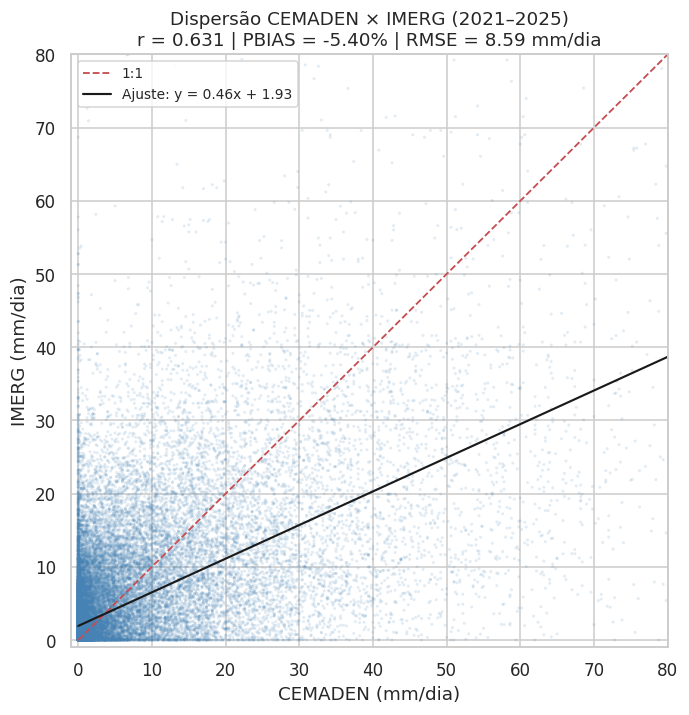

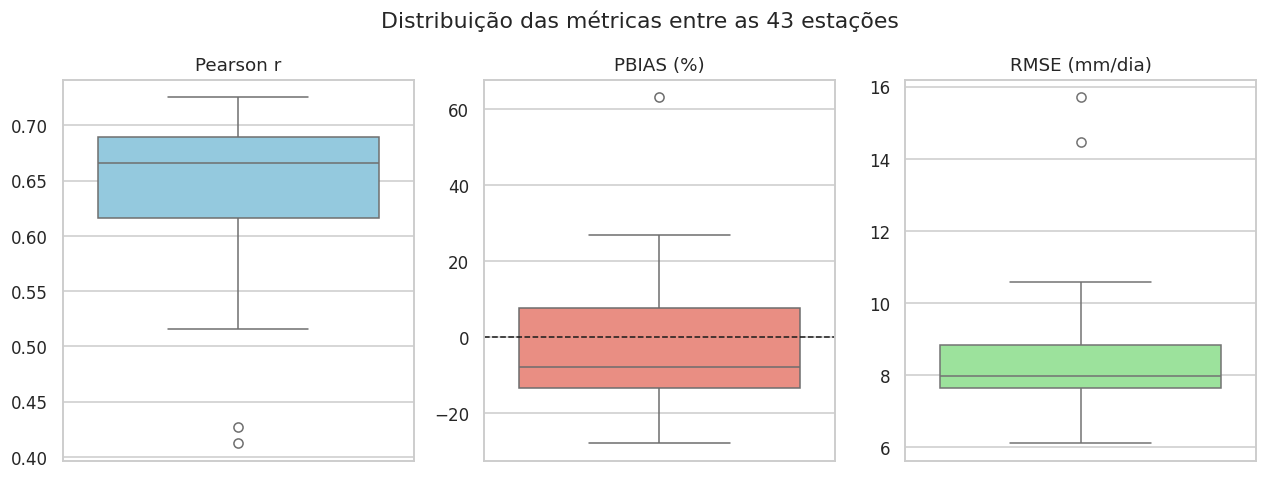

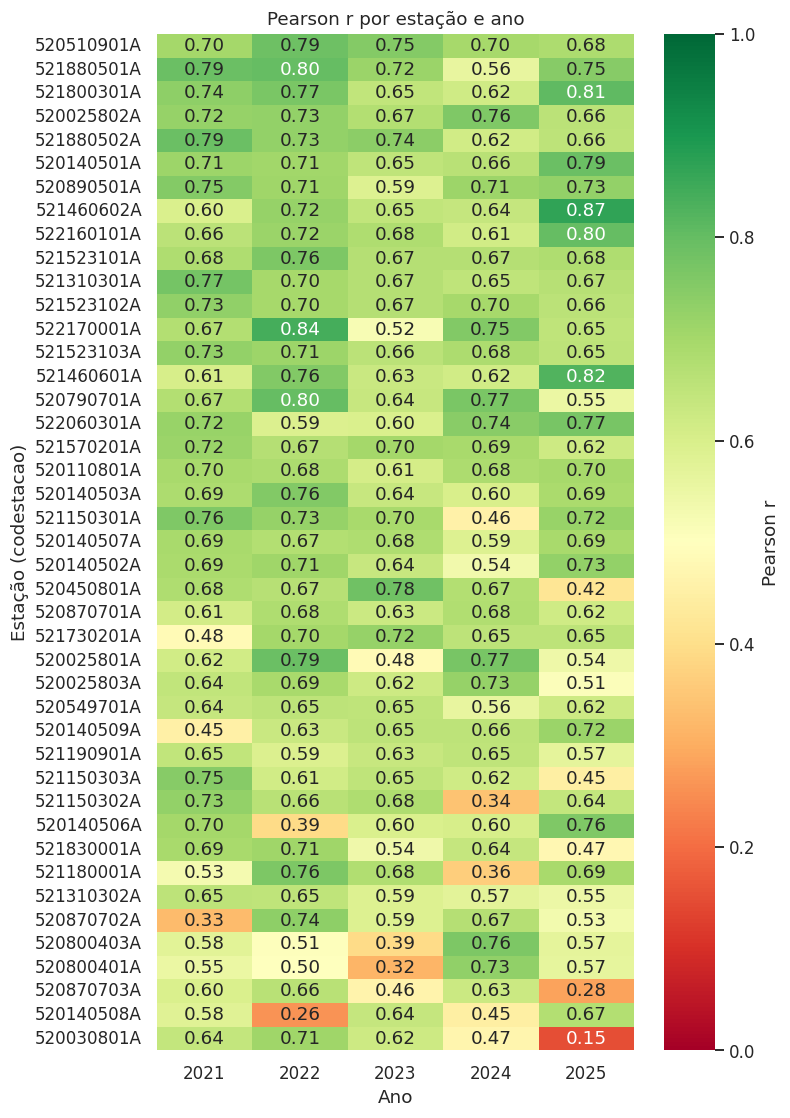

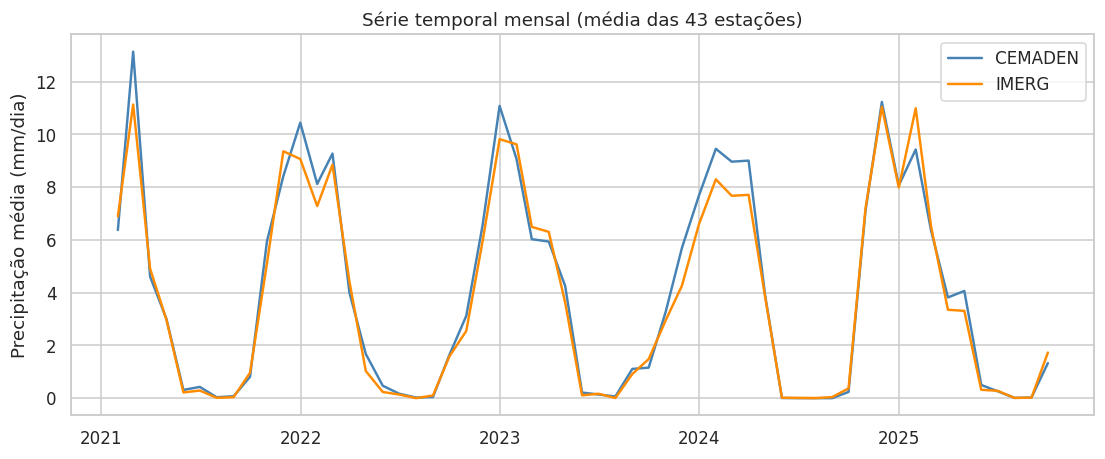

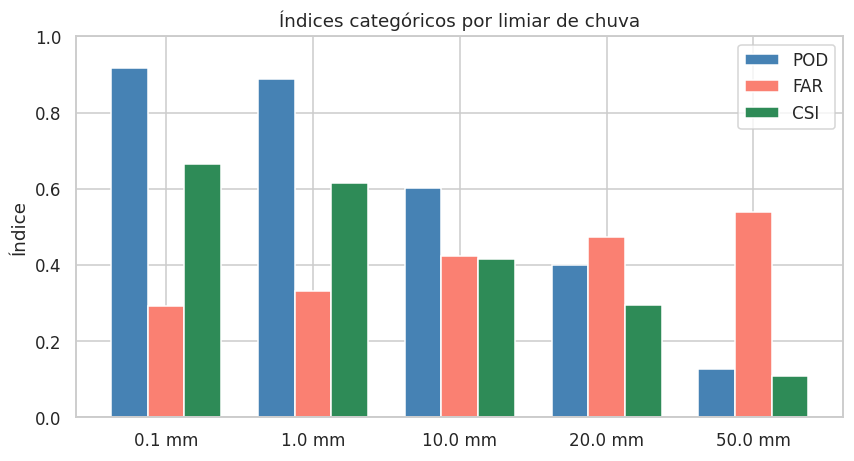


Gráficos salvos em: /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/resultados_CEMADEN_IMERG/06_graficos


In [ ]:
# ============================================================
# BLOCO 13 — GRÁFICOS PRINCIPAIS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

DIR_GRAF = SAIDA_DIR / "06_graficos"


# ------------------------------------------------------------
# 1. DISPERSÃO GLOBAL (CEMADEN × IMERG)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    base_validacao["precipitacao_cemaden"],
    base_validacao["precipitacao_imerg"],
    s=4, alpha=0.15, color="steelblue", edgecolor="none"
)

lim_max = 80
ax.plot([0, lim_max], [0, lim_max], "r--", lw=1.2, label="1:1")

# Linha de regressão
slope = metricas_globais["slope"]
intercept = metricas_globais["intercept"]
x_reg = np.array([0, lim_max])
ax.plot(
    x_reg, slope * x_reg + intercept,
    "k-", lw=1.4,
    label=f"Ajuste: y = {slope:.2f}x + {intercept:.2f}"
)

ax.set_xlim(-1, lim_max)
ax.set_ylim(-1, lim_max)
ax.set_xlabel("CEMADEN (mm/dia)")
ax.set_ylabel("IMERG (mm/dia)")
ax.set_title(
    "Dispersão CEMADEN × IMERG (2021–2025)\n"
    f"r = {metricas_globais['pearson_r']:.3f} | "
    f"PBIAS = {metricas_globais['pbias']:.2f}% | "
    f"RMSE = {metricas_globais['rmse']:.2f} mm/dia",
    fontsize=12
)
ax.legend(loc="upper left", fontsize=9)

plt.savefig(DIR_GRAF / "dispersao_global_CEMADEN_IMERG.png")
plt.show()


# ------------------------------------------------------------
# 2. BOXPLOT DAS MÉTRICAS POR ESTAÇÃO
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

sns.boxplot(y=metricas_est_cont["pearson_r"], ax=axes[0], color="skyblue")
axes[0].set_title("Pearson r")
axes[0].set_ylabel("")

sns.boxplot(y=metricas_est_cont["pbias"], ax=axes[1], color="salmon")
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_title("PBIAS (%)")
axes[1].set_ylabel("")

sns.boxplot(y=metricas_est_cont["rmse"], ax=axes[2], color="lightgreen")
axes[2].set_title("RMSE (mm/dia)")
axes[2].set_ylabel("")

plt.suptitle("Distribuição das métricas entre as 43 estações", y=1.02)
plt.savefig(DIR_GRAF / "boxplot_metricas_por_estacao.png")
plt.show()


# ------------------------------------------------------------
# 3. HEATMAP: Pearson r por estação × ano
# ------------------------------------------------------------
# Métricas de Pearson por (estação, ano)
pearson_por_ano = (
    base_validacao
    .groupby(["codestacao", "ano"])
    .apply(
        lambda g: stats.pearsonr(
            g["precipitacao_cemaden"], g["precipitacao_imerg"]
        )[0]
    )
    .rename("pearson_r")
    .reset_index()
)

matriz_pearson = pearson_por_ano.pivot(
    index="codestacao", columns="ano", values="pearson_r"
)

# Ordenar pelas médias
matriz_pearson = matriz_pearson.loc[
    matriz_pearson.mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(7, 12))
sns.heatmap(
    matriz_pearson, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0.0, vmax=1.0,
    cbar_kws={"label": "Pearson r"}, ax=ax
)
ax.set_title("Pearson r por estação e ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Estação (codestacao)")
plt.savefig(DIR_GRAF / "heatmap_pearson_estacao_ano.png")
plt.show()


# ------------------------------------------------------------
# 4. SÉRIE TEMPORAL MENSAL (média das estações)
# ------------------------------------------------------------
mensal = (
    base_validacao
    .set_index("data")
    .groupby(pd.Grouper(freq="ME"))[["precipitacao_cemaden", "precipitacao_imerg"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(
    mensal["data"], mensal["precipitacao_cemaden"],
    label="CEMADEN", color="steelblue", lw=1.6
)
ax.plot(
    mensal["data"], mensal["precipitacao_imerg"],
    label="IMERG", color="darkorange", lw=1.6
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_ylabel("Precipitação média (mm/dia)")
ax.set_title("Série temporal mensal (média das 43 estações)")
ax.legend()
plt.savefig(DIR_GRAF / "serie_mensal_media.png")
plt.show()


# ------------------------------------------------------------
# 5. GRÁFICO DE BARRAS: métricas categóricas por limiar
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(metricas_cat_globais))
largura = 0.25

ax.bar(x - largura, metricas_cat_globais["POD"], largura, label="POD", color="steelblue")
ax.bar(x,           metricas_cat_globais["FAR"], largura, label="FAR", color="salmon")
ax.bar(x + largura, metricas_cat_globais["CSI"], largura, label="CSI", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{l} mm" for l in metricas_cat_globais["limiar_mm"]]
)
ax.set_ylim(0, 1)
ax.set_ylabel("Índice")
ax.set_title("Índices categóricos por limiar de chuva")
ax.legend()
plt.savefig(DIR_GRAF / "barras_categoricas_por_limiar.png")
plt.show()


print("\nGráficos salvos em:", DIR_GRAF)

**Mapas espaciais**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 39.3 MB/s eta 0:00:00


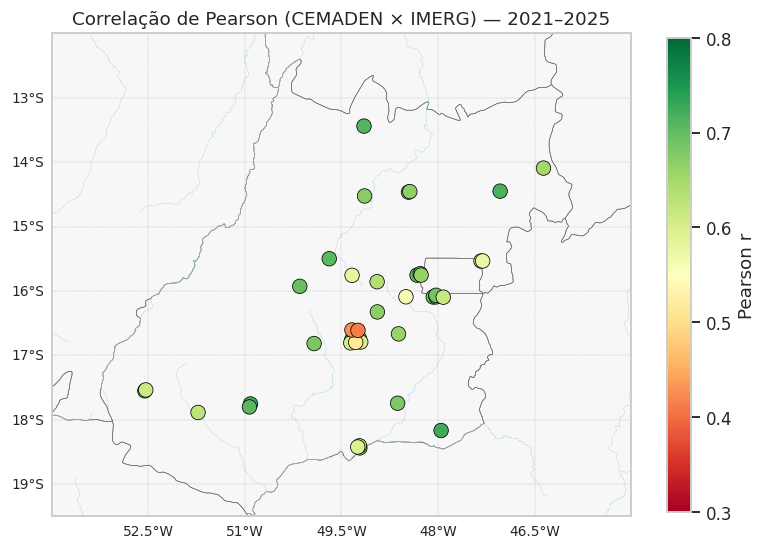

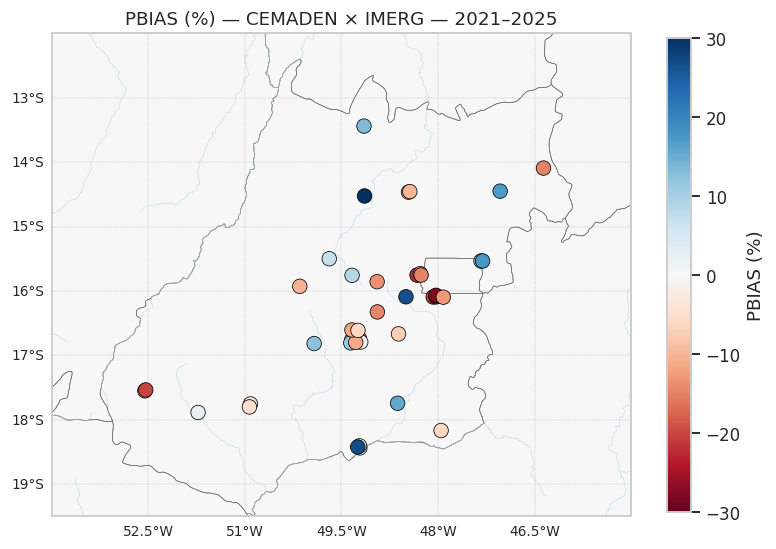

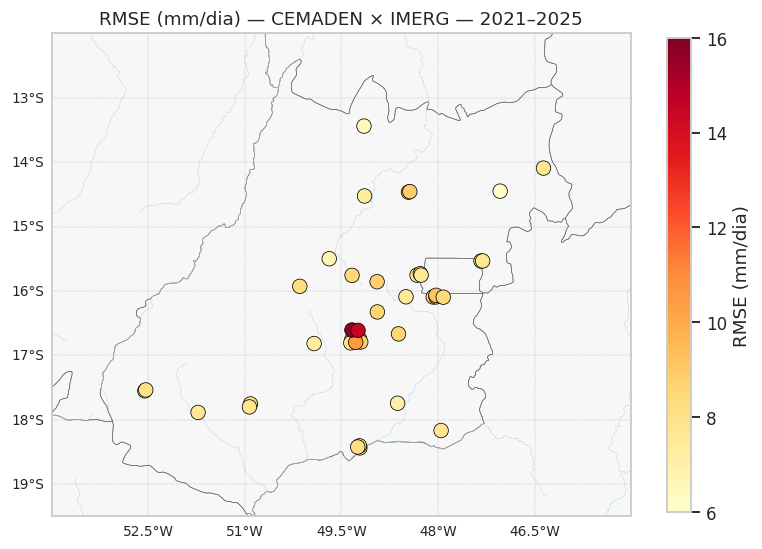

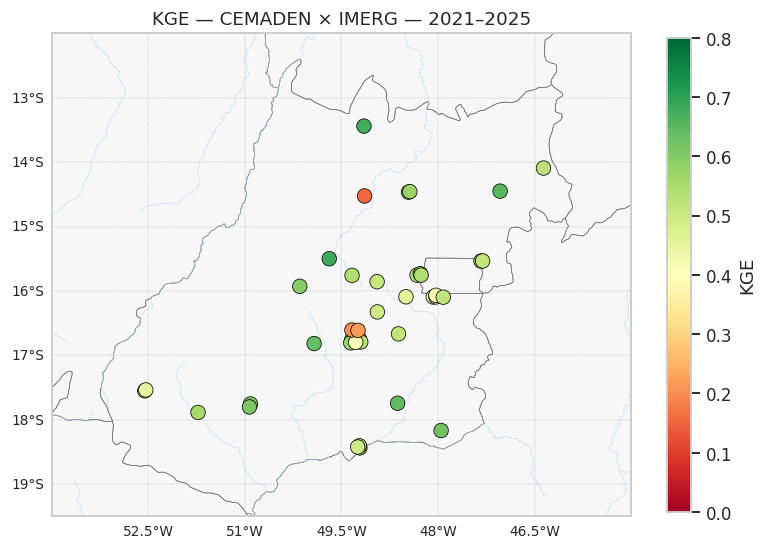

Mapas salvos em: /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/resultados_CEMADEN_IMERG/07_mapas


In [ ]:
# ============================================================
# BLOCO 14 — MAPAS ESPACIAIS DAS MÉTRICAS
# ============================================================
!pip install cartopy
import cartopy
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300

DIR_MAPAS = SAIDA_DIR / "07_mapas"
DIR_MAPAS.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. FUNÇÃO AUXILIAR DE MAPA
# ------------------------------------------------------------
def plotar_mapa_metrica(
    tabela,
    coluna,
    titulo,
    cmap="RdYlGn",
    vmin=None,
    vmax=None,
    center=None,
    arquivo_saida=None,
    rotulo_cbar=None
):
    """
    Plota um mapa com estações coloridas por uma métrica.
    """
    fig = plt.figure(figsize=(8.5, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Extensão de Goiás + margem
    ax.set_extent([-54.0, -45.0, -19.5, -12.0], crs=ccrs.PlateCarree())

    # Fundo
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="gray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor="dimgray")
    ax.add_feature(cfeature.LAND, facecolor="#f7f7f7")
    ax.add_feature(cfeature.RIVERS, linewidth=0.3, edgecolor="lightblue")

    # Normalização
    if center is not None:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)
    else:
        norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # Dispersão
    sc = ax.scatter(
        tabela["longitude"],
        tabela["latitude"],
        c=tabela[coluna],
        s=90,
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidth=0.5,
        transform=ccrs.PlateCarree(),
        zorder=5
    )

    # Barra de cores
    cbar = plt.colorbar(
        sc, ax=ax, orientation="vertical",
        shrink=0.7, pad=0.05
    )
    cbar.set_label(rotulo_cbar or coluna)

    # Grade
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.3,
        color="gray", alpha=0.5, linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

    ax.set_title(titulo, fontsize=12)

    if arquivo_saida:
        plt.savefig(arquivo_saida, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# 2. MAPA — PEARSON r
# ------------------------------------------------------------
plotar_mapa_metrica(
    metricas_est_cont,
    coluna="pearson_r",
    titulo="Correlação de Pearson (CEMADEN × IMERG) — 2021–2025",
    cmap="RdYlGn",
    vmin=0.3, vmax=0.8,
    arquivo_saida=DIR_MAPAS / "mapa_pearson_r.png",
    rotulo_cbar="Pearson r"
)


# ------------------------------------------------------------
# 3. MAPA — PBIAS
# ------------------------------------------------------------
plotar_mapa_metrica(
    metricas_est_cont,
    coluna="pbias",
    titulo="PBIAS (%) — CEMADEN × IMERG — 2021–2025",
    cmap="RdBu",
    vmin=-30, vmax=30, center=0,
    arquivo_saida=DIR_MAPAS / "mapa_pbias.png",
    rotulo_cbar="PBIAS (%)"
)


# ------------------------------------------------------------
# 4. MAPA — RMSE
# ------------------------------------------------------------
plotar_mapa_metrica(
    metricas_est_cont,
    coluna="rmse",
    titulo="RMSE (mm/dia) — CEMADEN × IMERG — 2021–2025",
    cmap="YlOrRd",
    vmin=6, vmax=16,
    arquivo_saida=DIR_MAPAS / "mapa_rmse.png",
    rotulo_cbar="RMSE (mm/dia)"
)


# ------------------------------------------------------------
# 5. MAPA — KGE
# ------------------------------------------------------------
plotar_mapa_metrica(
    metricas_est_cont,
    coluna="kge",
    titulo="KGE — CEMADEN × IMERG — 2021–2025",
    cmap="RdYlGn",
    vmin=0.0, vmax=0.8,
    arquivo_saida=DIR_MAPAS / "mapa_kge.png",
    rotulo_cbar="KGE"
)


print("Mapas salvos em:", DIR_MAPAS)

**Análise por altitude**

ANÁLISE POR ALTITUDE — via MDE GeoTIFF local
MDE: /content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/MDE_GO.tif

Metadados do MDE:
  CRS:        None
  Shape:      8526 × 8811
  Resolução:  (0.0008333333333333326, 0.0008333333333333334)
  Bounds:     BoundingBox(left=-53.249166667, bottom=-19.499166667, right=-45.906666667, top=-12.394166667)
  Nodata:     -9999.0
  Bandas:     1

MDE em EPSG:4326 — sem reprojeção necessária.

Extraindo altitude nas coordenadas das estações...

Todas as estações tiveram altitude extraída com sucesso.

Resumo da altitude (m):
count      43.0
mean      786.5
std       201.3
min       405.0
25%       644.0
50%       809.0
75%       909.0
max      1184.0
Name: altitude_m, dtype: float64

CORRELAÇÃO COM ALTITUDE (Spearman)


,metrica,spearman_rho,p_valor,significativo_5%
0,pearson_r,-0.098086,0.531478,False
1,pbias,-0.543436,0.000166,True
2,rmse,0.140975,0.367212,False
3,kge,-0.420282,0.005016,True
4,nse,0.050742,0.746589,False
5,completude,0.314372,0.040062,True


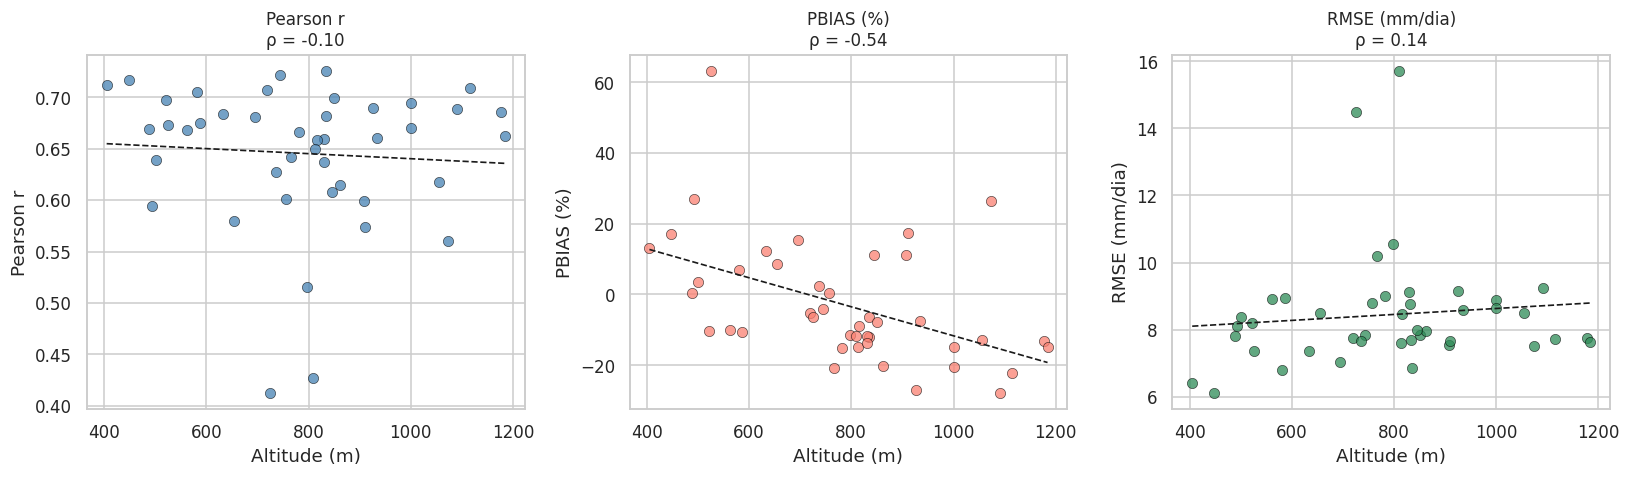

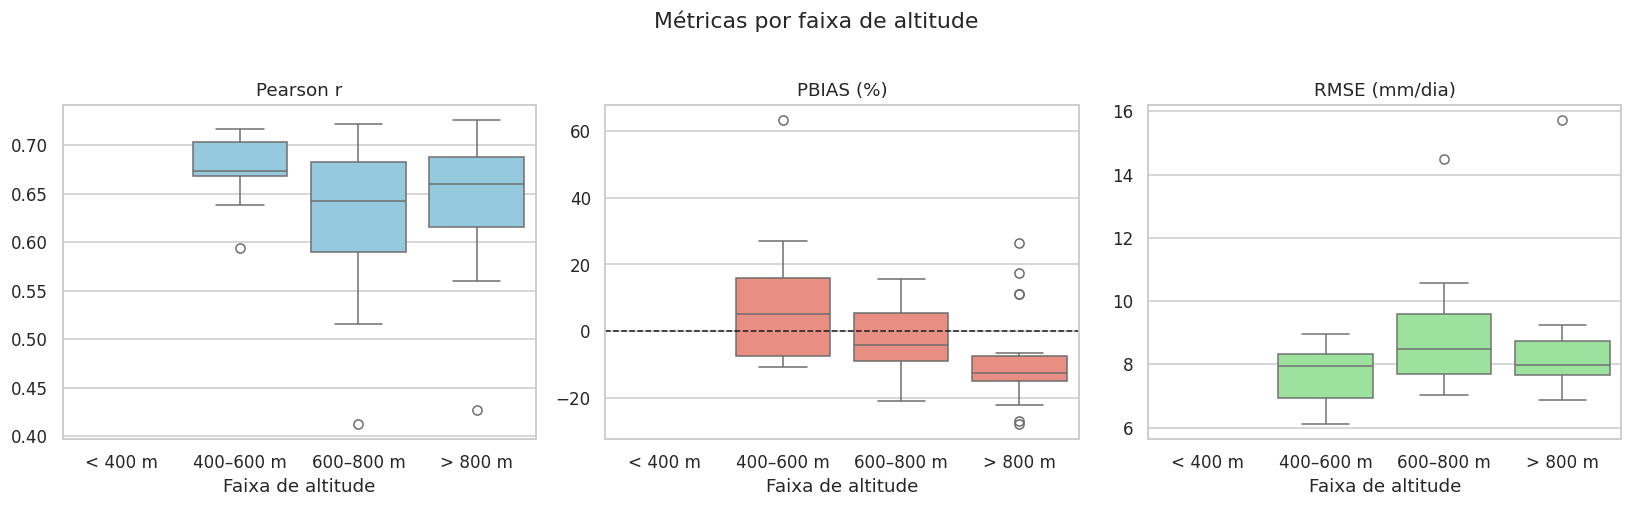


Análise de altitude concluída.


In [ ]:
# ============================================================
# BLOCO 15 — ANÁLISE POR ALTITUDE VIA MDE LOCAL
# ============================================================

import rasterio
from rasterio.transform import rowcol

print("=" * 60)
print("ANÁLISE POR ALTITUDE — via MDE GeoTIFF local")
print("=" * 60)


# ------------------------------------------------------------
# 1. CAMINHO DO MDE
# ------------------------------------------------------------
# ⚠️ AJUSTE O CAMINHO ABAIXO PARA O SEU ARQUIVO .tif
MDE_PATH = BASE_DIR / "MDE" / "MDE_Goias.tif"

# Se estiver em outro lugar, descomente e edite:
MDE_PATH = Path("/content/drive/MyDrive/UFG/Doutorado/Artigos/SBSR/MDE_GO.tif")

if not MDE_PATH.exists():
    raise FileNotFoundError(
        f"MDE não encontrado em: {MDE_PATH}\n"
        f"Ajuste a variável MDE_PATH para o caminho correto."
    )

print(f"MDE: {MDE_PATH}")


# ------------------------------------------------------------
# 2. ABRIR O MDE E MOSTRAR METADADOS
# ------------------------------------------------------------
with rasterio.open(MDE_PATH) as src:

    print("\nMetadados do MDE:")
    print(f"  CRS:        {src.crs}")
    print(f"  Shape:      {src.height} × {src.width}")
    print(f"  Resolução:  {src.res}")
    print(f"  Bounds:     {src.bounds}")
    print(f"  Nodata:     {src.nodata}")
    print(f"  Bandas:     {src.count}")

    crs_mde = src.crs
    bounds_mde = src.bounds


# ------------------------------------------------------------
# 3. REPROJETAR COORDENADAS DAS ESTAÇÕES PARA O CRS DO MDE
# ------------------------------------------------------------
# As estações estão em EPSG:4326 (lat/lon).
# O MDE pode estar em EPSG:4326 ou em UTM (EPSG:31982/31983 etc.).

from pyproj import Transformer

if crs_mde is None or str(crs_mde).upper().endswith("4326"):
    # Já está em lat/lon
    print("\nMDE em EPSG:4326 — sem reprojeção necessária.")
    lons_mde = metricas_est_cont["longitude"].values
    lats_mde = metricas_est_cont["latitude"].values

else:
    print(f"\nReprojetando estações de EPSG:4326 para {crs_mde}...")
    transformer = Transformer.from_crs(
        "EPSG:4326",
        crs_mde,
        always_xy=True
    )
    lons_mde, lats_mde = transformer.transform(
        metricas_est_cont["longitude"].values,
        metricas_est_cont["latitude"].values
    )


# ------------------------------------------------------------
# 4. EXTRAIR ALTITUDE EM CADA ESTAÇÃO
# ------------------------------------------------------------
print("\nExtraindo altitude nas coordenadas das estações...")

altitudes_vals = []

with rasterio.open(MDE_PATH) as src:

    for lon, lat in zip(lons_mde, lats_mde):

        try:
            # Amostragem bilinear (mais precisa) com fallback para nearest
            valor = next(
                src.sample(
                    [(lon, lat)],
                    indexes=1,
                    masked=True
                )
            )

            altitudes_vals.append(float(valor))

        except Exception as e:
            print(f"  Erro em ({lon:.4f}, {lat:.4f}): {e}")
            altitudes_vals.append(np.nan)


# ------------------------------------------------------------
# 5. MONTAR DATAFRAME DE ALTITUDE
# ------------------------------------------------------------
altitudes = pd.DataFrame({
    "codestacao": metricas_est_cont["codestacao"].values,
    "altitude_m": altitudes_vals
})


# ------------------------------------------------------------
# 6. VERIFICAR VALORES AUSENTES
# ------------------------------------------------------------
n_nan = altitudes["altitude_m"].isna().sum()

if n_nan > 0:
    print(f"\n⚠️  {n_nan} estações ficaram sem altitude (fora do MDE).")
    print("Verifique se o MDE cobre todo o estado de Goiás.")
    display(altitudes[altitudes["altitude_m"].isna()])
else:
    print("\nTodas as estações tiveram altitude extraída com sucesso.")

print("\nResumo da altitude (m):")
print(altitudes["altitude_m"].describe().round(1))


# ------------------------------------------------------------
# 7. JUNTAR COM MÉTRICAS
# ------------------------------------------------------------
metricas_est_cont_alt = metricas_est_cont.merge(
    altitudes,
    on="codestacao",
    how="left"
)


# ------------------------------------------------------------
# 8. CORRELAÇÃO COM MÉTRICAS (Spearman)
# ------------------------------------------------------------
metricas_para_correlacionar = [
    "pearson_r", "pbias", "rmse", "kge", "nse", "completude"
]

print("\n" + "=" * 60)
print("CORRELAÇÃO COM ALTITUDE (Spearman)")
print("=" * 60)

correlacoes = []

for m in metricas_para_correlacionar:

    sub = metricas_est_cont_alt[
        ["altitude_m", m]
    ].dropna()

    if len(sub) < 3:
        correlacoes.append({
            "metrica": m,
            "spearman_rho": np.nan,
            "p_valor": np.nan,
            "significativo_5%": False
        })
        continue

    rho, p = stats.spearmanr(
        sub["altitude_m"],
        sub[m]
    )

    correlacoes.append({
        "metrica": m,
        "spearman_rho": rho,
        "p_valor": p,
        "significativo_5%": p < 0.05
    })

correlacoes = pd.DataFrame(correlacoes)
display(correlacoes)


# ------------------------------------------------------------
# 9. GRÁFICO: ALTITUDE × MÉTRICAS
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pares = [
    ("altitude_m", "pearson_r", "Pearson r", "steelblue"),
    ("altitude_m", "pbias", "PBIAS (%)", "salmon"),
    ("altitude_m", "rmse", "RMSE (mm/dia)", "seagreen")
]

for ax, (xcol, ycol, titulo, cor) in zip(axes, pares):

    sub = metricas_est_cont_alt[[xcol, ycol]].dropna()

    ax.scatter(
        sub[xcol], sub[ycol],
        s=45, color=cor, alpha=0.75,
        edgecolor="black", linewidth=0.4
    )

    if len(sub) >= 3:
        slope, intercept, r_val, p_val, _ = stats.linregress(
            sub[xcol], sub[ycol]
        )
        x_reg = np.linspace(sub[xcol].min(), sub[xcol].max(), 50)
        ax.plot(x_reg, slope * x_reg + intercept, "k--", lw=1.1)

        rho_aux, _ = stats.spearmanr(sub[xcol], sub[ycol])
        ax.set_title(
            f"{titulo}\nρ = {rho_aux:.2f}",
            fontsize=11
        )

    ax.set_xlabel("Altitude (m)")
    ax.set_ylabel(titulo)

plt.tight_layout()
plt.savefig(
    DIR_GRAF / "altitude_vs_metricas.png",
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 10. BOXPLOT POR FAIXA DE ALTITUDE
# ------------------------------------------------------------
metricas_est_cont_alt["faixa_altitude"] = pd.cut(
    metricas_est_cont_alt["altitude_m"],
    bins=[0, 400, 600, 800, 1200],
    labels=["< 400 m", "400–600 m", "600–800 m", "> 800 m"]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (ycol, titulo, cor) in zip(
    axes,
    [
        ("pearson_r", "Pearson r", "skyblue"),
        ("pbias", "PBIAS (%)", "salmon"),
        ("rmse", "RMSE (mm/dia)", "lightgreen")
    ]
):
    sns.boxplot(
        x="faixa_altitude",
        y=ycol,
        data=metricas_est_cont_alt,
        ax=ax,
        color=cor
    )

    if ycol == "pbias":
        ax.axhline(0, color="k", ls="--", lw=1)

    ax.set_title(titulo)
    ax.set_xlabel("Faixa de altitude")
    ax.set_ylabel("")

plt.suptitle("Métricas por faixa de altitude", y=1.02)
plt.tight_layout()
plt.savefig(
    DIR_GRAF / "boxplot_metricas_faixa_altitude.png",
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 11. EXPORTAR
# ------------------------------------------------------------
altitudes.to_csv(
    SAIDA_DIR / "05_altitude" / "altitude_estacoes.csv",
    index=False,
    encoding="utf-8-sig"
)

metricas_est_cont_alt.to_csv(
    SAIDA_DIR / "05_altitude" / "metricas_por_estacao_com_altitude.csv",
    index=False,
    encoding="utf-8-sig"
)

correlacoes.to_csv(
    SAIDA_DIR / "05_altitude" / "correlacoes_altitude.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nAnálise de altitude concluída.")